# EGX30 Historical Analysis
**Full Project Notebook** — Data Analysis with ARIMA Forecasting

Covers: Data Loading → Preprocessing → Exploratory Data Analysis → Feature Engineering → ARIMA Forecasting

---
## ⚙️ SETUP — Install & Import Everything

In [2]:
!pip install pandas numpy matplotlib seaborn statsmodels scipy scikit-learn -q
print('Installation complete.')

Installation complete.


In [3]:
# Core data manipulation
# Statistical testing, time-series modeling, and visualization
# sklearn used only for evaluation metrics (RMSE, MAE)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
COLORS = {
    'blue':'#2563eb','green':'#16a34a','red':'#dc2626',
    'purple':'#9333ea','orange':'#ea580c','gray':'#6b7280'
}
KEY_EVENTS = {
    '2016-11-03': ('2016 EGP Float',      'red'),
    '2020-03-08': ('COVID Crash',          'red'),
    '2022-03-21': ('2022 Devaluation',     'orange'),
    '2024-03-06': ('2024 Currency Crisis', 'orange'),
}
print('All libraries imported.')

All libraries imported.


---
## 📁 PHASE 3 — Data Loading & Inspection

In [4]:
from google.colab import files
print('Upload EGX_30_Historical_Data.csv (the original raw file)')
uploaded = files.upload()

Upload EGX_30_Historical_Data.csv (the original raw file)


Saving EGX_30_Historical_Data.csv to EGX_30_Historical_Data.csv


In [5]:
# ── Load raw CSV
import io
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))

print('=== RAW DATA INSPECTION ===')
print('Shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
print('\nFirst 5 rows:')
print(df_raw.head())
print('\nData types:')
print(df_raw.dtypes)
print('\nNull values:')
print(df_raw.isnull().sum())
print('\nDate range (raw):', df_raw['Date'].iloc[-1], '→', df_raw['Date'].iloc[0])

=== RAW DATA INSPECTION ===
Shape: (3001, 7)
Columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

First 5 rows:
         Date      Price       Open       High        Low     Vol. Change %
0  05/05/2026  52,557.63  51,973.50  52,595.35  51,367.47  496.94M    1.12%
1  05/04/2026  51,973.50  52,312.70  52,704.76  51,818.87  692.00M   -0.65%
2  05/03/2026  52,312.70  51,760.97  52,393.85  51,818.92  700.54M    1.07%
3  04/30/2026  51,760.97  52,383.13  52,538.84  51,748.64  637.54M   -1.19%
4  04/29/2026  52,383.13  52,230.61  52,431.85  52,096.15  420.47M    0.29%

Data types:
Date        object
Price       object
Open        object
High        object
Low         object
Vol.        object
Change %    object
dtype: object

Null values:
Date        0
Price       0
Open        0
High        0
Low         0
Vol.        9
Change %    0
dtype: int64

Date range (raw): 01/02/2014 → 05/05/2026


In [6]:
# Log returns are preferred over simple returns: they are time-additive,
# more symmetric, and better approximate normality — standard in quantitative finance
# ffill for the 9 missing volume values: use last known value rather than interpolating
# ADF test: H0 = series has a unit root (non-stationary). We want p < 0.05 to reject H0

# ── PHASE 4: Clean & Parse
df = df_raw.copy()

# Parse date
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df = df.sort_values('Date').reset_index(drop=True)

# Clean numeric columns (remove commas)
for col in ['Price', 'Open', 'High', 'Low']:
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

# Parse volume (e.g. '496.94M' → 496940000)
def parse_volume(v):
    v = str(v).strip()
    if v.endswith('M'): return float(v[:-1]) * 1e6
    elif v.endswith('B'): return float(v[:-1]) * 1e9
    elif v.endswith('K'): return float(v[:-1]) * 1e3
    else: return float(v.replace(',', ''))

df['Volume']     = df['Vol.'].apply(parse_volume)
df['Change_Pct'] = df['Change %'].str.replace('%', '').astype(float)
df = df.rename(columns={'Price': 'Close'})
df = df[['Date','Open','High','Low','Close','Volume','Change_Pct']]
df = df.set_index('Date')

# Fill 9 missing volume values
df['Volume'] = df['Volume'].ffill()

# Compute returns
df['Return']     = df['Close'].pct_change()
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna()

print('=== CLEANING COMPLETE ===')
print(f'Shape          : {df.shape}')
print(f'Date range     : {df.index[0].date()} → {df.index[-1].date()}')
print(f'Null values    : {df.isnull().sum().sum()}')
print(f'Volume nulls   : filled with forward-fill')
print()
print('Cleaned sample:')
print(df.head())

# ADF stationarity test
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'--- ADF Test: {name} ---')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.6f}')
    print(f'  Result        : {"STATIONARY ✓" if result[1]<0.05 else "NON-STATIONARY ✗"}')
    print()

print('\n=== STATIONARITY TESTS ===')
adf_test(df['Close'],      'Close Price')
adf_test(df['Log_Return'], 'Log Returns')
print('→ Prices are non-stationary (expected — prices trend)')
print('→ Log returns are stationary → we model returns, not prices')

=== CLEANING COMPLETE ===
Shape          : (3000, 8)
Date range     : 2014-01-05 → 2026-05-05
Null values    : 0
Volume nulls   : filled with forward-fill

Cleaned sample:
               Open     High      Low    Close       Volume  Change_Pct  \
Date                                                                      
2014-01-05  6819.27  6855.34  6819.27  6853.70  174090000.0        0.62   
2014-01-06  6862.79  6875.74  6801.33  6801.33  172020000.0       -0.76   
2014-01-08  6806.03  6887.96  6805.83  6887.48  175110000.0        1.27   
2014-01-09  6928.68  6986.14  6928.68  6975.04  178640000.0        1.27   
2014-01-12  7018.11  7117.46  7018.11  7116.81  248950000.0        2.03   

              Return  Log_Return  
Date                              
2014-01-05  0.006225    0.006206  
2014-01-06 -0.007641   -0.007670  
2014-01-08  0.012667    0.012587  
2014-01-09  0.012713    0.012633  
2014-01-12  0.020325    0.020122  

=== STATIONARITY TESTS ===
--- ADF Test: Close Price ---

In [7]:
print('=== EGX30 Dataset Summary ===')
print(f'Trading Days  : {len(df):,}')
print(f'Start Level   : {df["Close"].iloc[0]:,.2f}')
print(f'End Level     : {df["Close"].iloc[-1]:,.2f}')
print(f'Total Return  : {(df["Close"].iloc[-1]/df["Close"].iloc[0]-1)*100:.1f}%')
print(f'Mean Daily Ret: {df["Log_Return"].mean()*100:.4f}%')
print(f'Daily Std     : {df["Log_Return"].std()*100:.4f}%')
print(f'Worst Day     : {df["Log_Return"].min()*100:.2f}%')
print(f'Best Day      : {df["Log_Return"].max()*100:.2f}%')
print(f'Annualized Vol: {df["Log_Return"].std()*np.sqrt(252)*100:.2f}%')

=== EGX30 Dataset Summary ===
Trading Days  : 3,000
Start Level   : 6,853.70
End Level     : 52,557.63
Total Return  : 666.9%
Mean Daily Ret: 0.0681%
Daily Std     : 1.3674%
Worst Day     : -9.81%
Best Day      : 6.49%
Annualized Vol: 21.71%


---
## 📊 PHASE 5 — Exploratory Data Analysis EDA

### 5.1 — Price History & Key Events

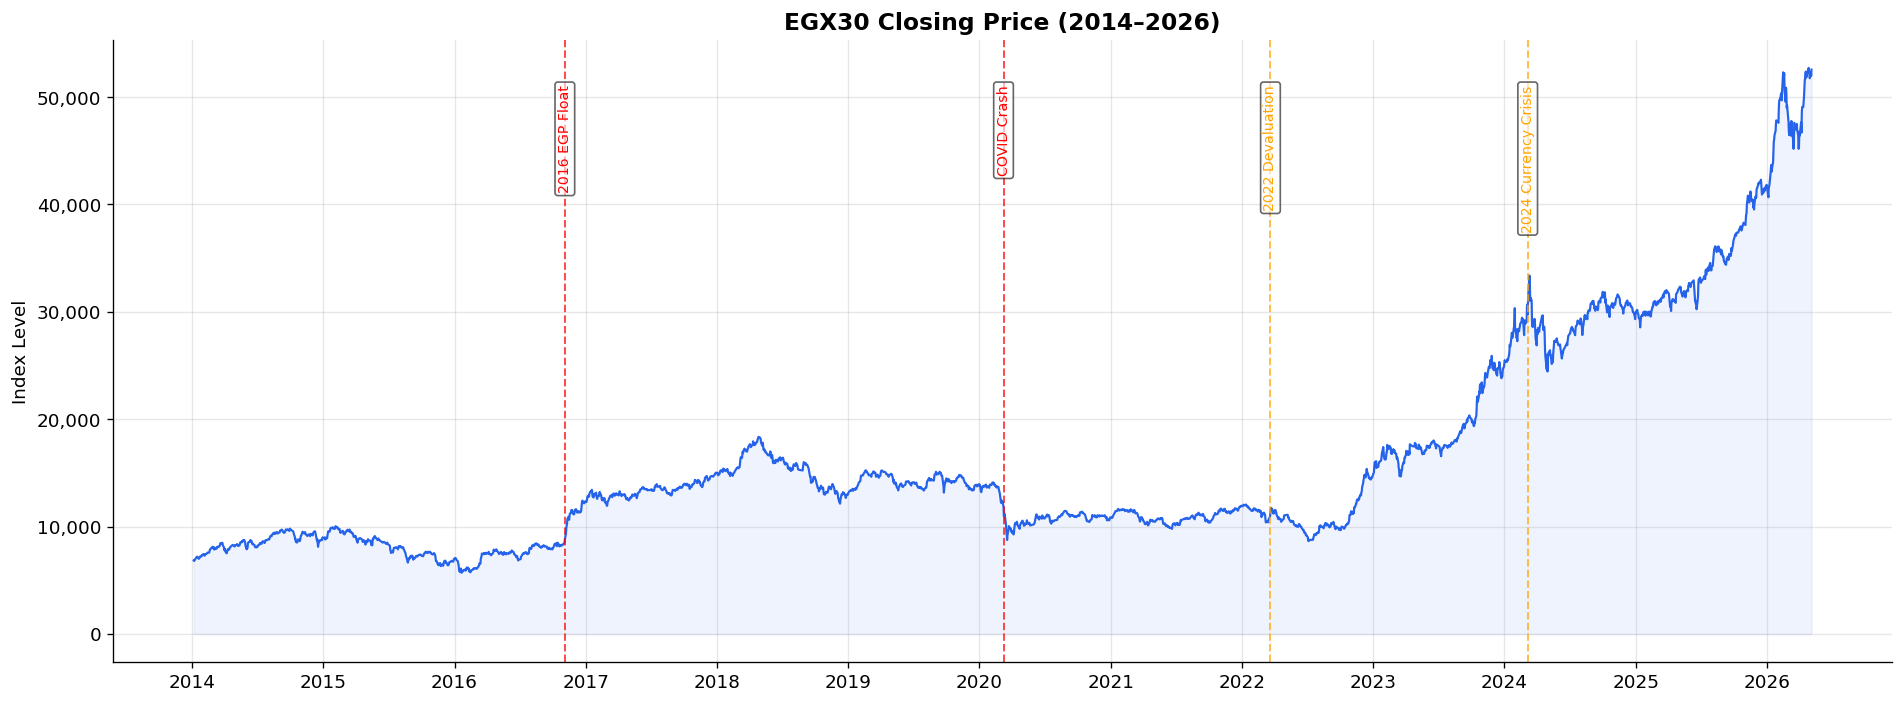

In [8]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df.index, df['Close'], color=COLORS['blue'], linewidth=1.3, label='EGX30 Close')
ax.fill_between(df.index, df['Close'], alpha=0.07, color=COLORS['blue'])

ymax = df['Close'].max()
for date_str, (label, color) in KEY_EVENTS.items():
    d = pd.Timestamp(date_str)
    ax.axvline(x=d, color=color, linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(d, ymax*0.97, label, fontsize=8.5, color=color,
            ha='center', va='top', rotation=90,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))

ax.set_title('EGX30 Closing Price (2014–2026)', fontsize=14, fontweight='bold')
ax.set_ylabel('Index Level')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('01_price_history.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 — Returns Distribution & Normality

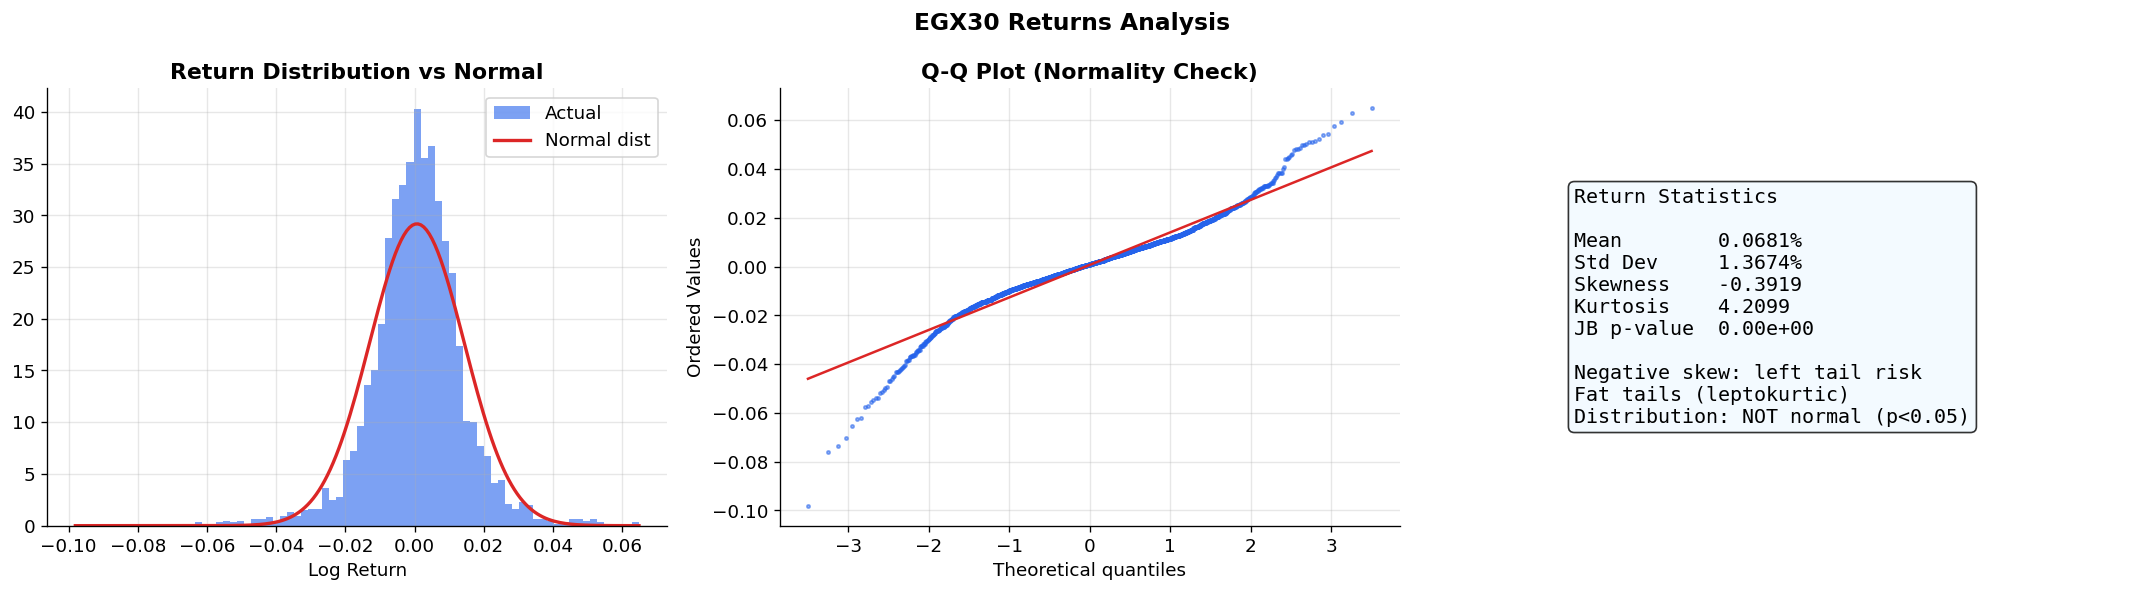

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mu, sigma = df['Log_Return'].mean(), df['Log_Return'].std()
x = np.linspace(df['Log_Return'].min(), df['Log_Return'].max(), 200)
axes[0].hist(df['Log_Return'], bins=80, density=True,
             color=COLORS['blue'], alpha=0.6, label='Actual')
axes[0].plot(x, stats.norm.pdf(x, mu, sigma),
             color=COLORS['red'], linewidth=2, label='Normal dist')
axes[0].set_title('Return Distribution vs Normal', fontweight='bold')
axes[0].set_xlabel('Log Return')
axes[0].legend()

stats.probplot(df['Log_Return'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)', fontweight='bold')
axes[1].get_lines()[0].set(color=COLORS['blue'], markersize=2, alpha=0.5)
axes[1].get_lines()[1].set(color=COLORS['red'])

skew = df['Log_Return'].skew()
kurt = df['Log_Return'].kurtosis()
_, jb_p = stats.jarque_bera(df['Log_Return'])
axes[2].axis('off')
stats_text = (
    f"Return Statistics\n\n"
    f"Mean        {mu*100:.4f}%\n"
    f"Std Dev     {sigma*100:.4f}%\n"
    f"Skewness    {skew:.4f}\n"
    f"Kurtosis    {kurt:.4f}\n"
    f"JB p-value  {jb_p:.2e}\n\n"
    f"{'Negative skew: left tail risk' if skew<0 else 'Positive skew: right tail'}\n"
    f"{'Fat tails (leptokurtic)' if kurt>0 else 'Thin tails'}\n"
    f"Distribution: NOT normal (p<0.05)"
)
axes[2].text(0.1, 0.5, stats_text, transform=axes[2].transAxes,
             fontsize=12, verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f0f9ff', alpha=0.8))

plt.suptitle('EGX30 Returns Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 — Rolling Volatility & Volatility Clustering

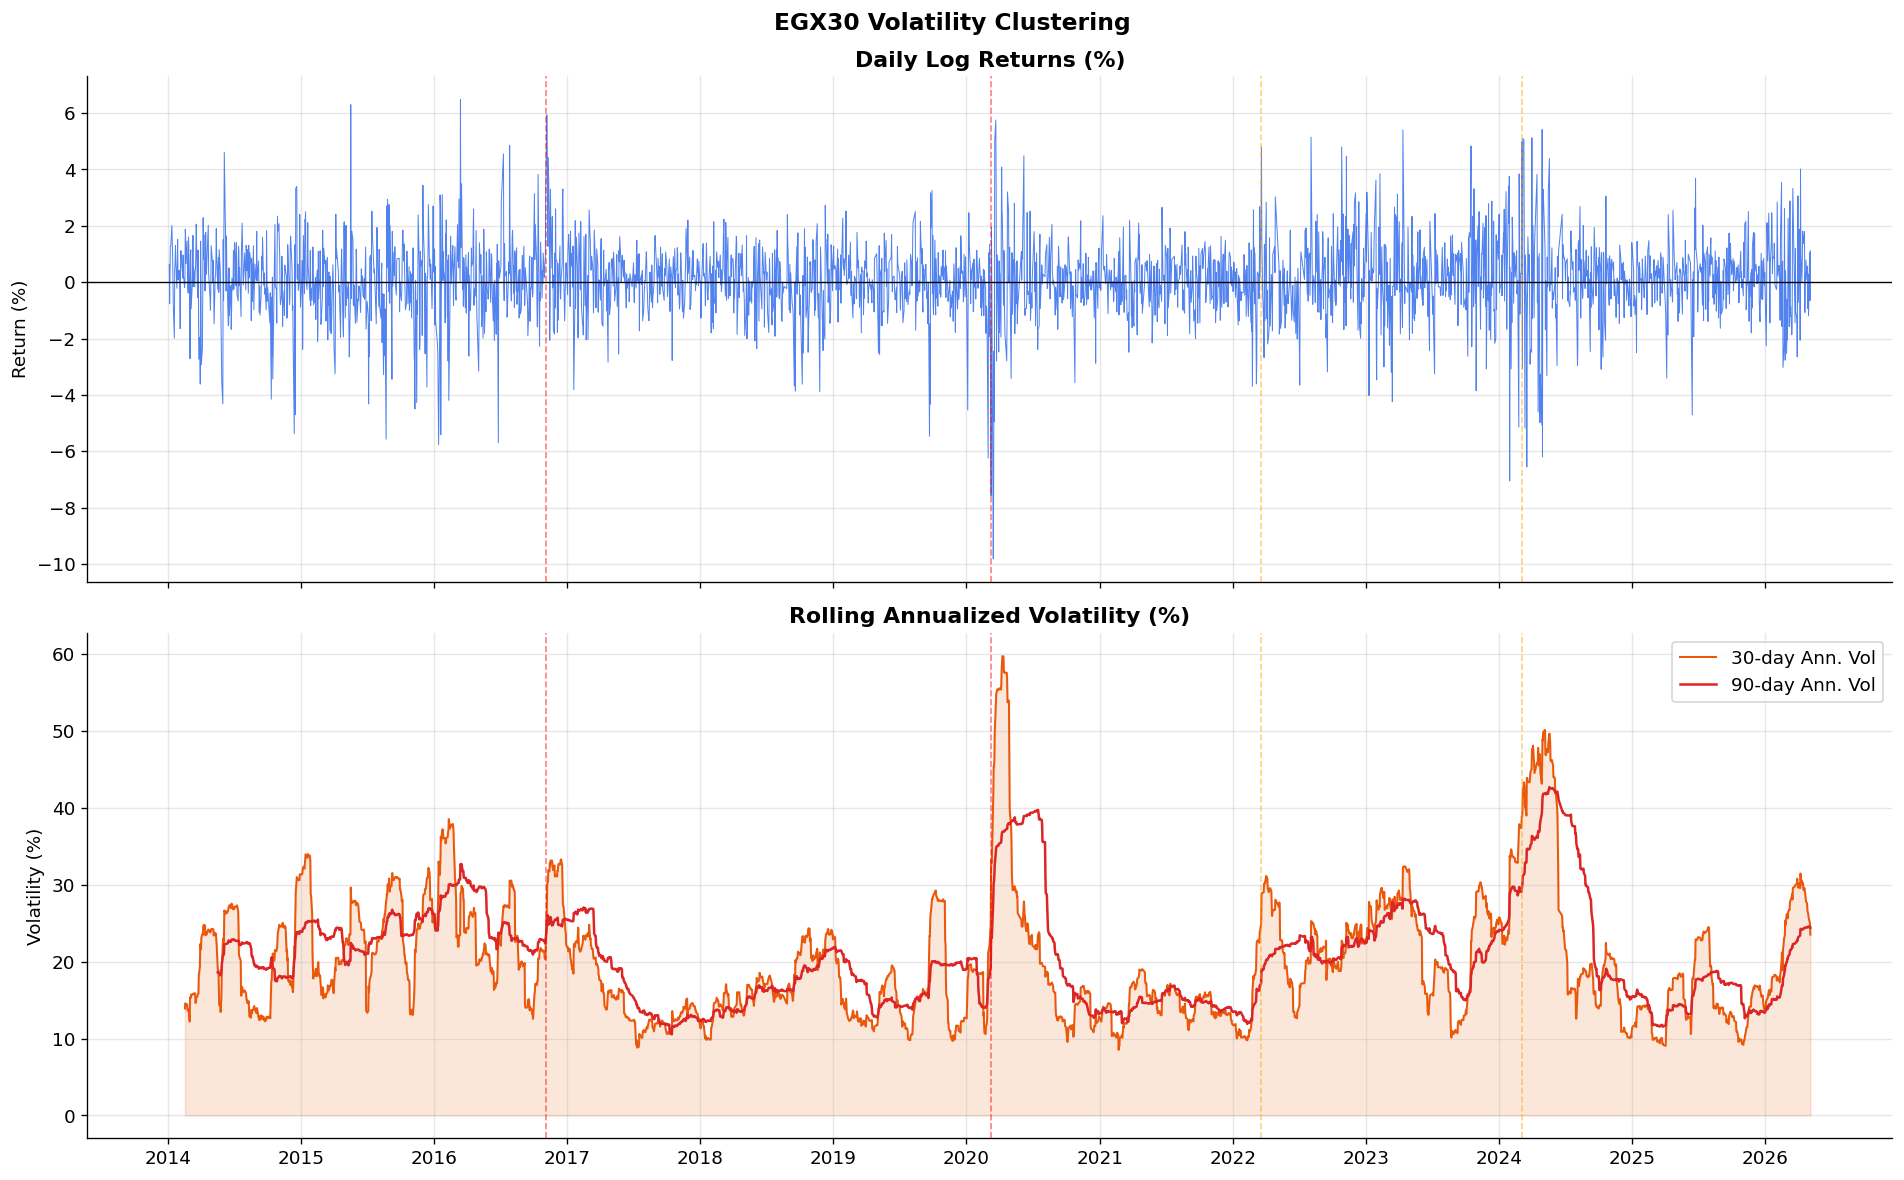

In [10]:
# Rolling std * sqrt(252) converts daily std to annualized volatility
# 252 = approximate number of trading days per year on the EGX
# Two windows capture volatility at different time scales:
# 30-day = short-term spikes, 90-day = sustained high-volatility regimes

df['Vol_30'] = df['Log_Return'].rolling(30).std()  * np.sqrt(252) * 100
df['Vol_90'] = df['Log_Return'].rolling(90).std()  * np.sqrt(252) * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(df.index, df['Log_Return']*100,
             color=COLORS['blue'], linewidth=0.6, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Daily Log Returns (%)', fontweight='bold')
axes[0].set_ylabel('Return (%)')

axes[1].plot(df.index, df['Vol_30'],
             color=COLORS['orange'], linewidth=1.2, label='30-day Ann. Vol')
axes[1].plot(df.index, df['Vol_90'],
             color=COLORS['red'], linewidth=1.5, label='90-day Ann. Vol')
axes[1].fill_between(df.index, df['Vol_30'], alpha=0.15, color=COLORS['orange'])
axes[1].set_title('Rolling Annualized Volatility (%)', fontweight='bold')
axes[1].set_ylabel('Volatility (%)')
axes[1].legend()

for ax in axes:
    for date_str, (label, color) in KEY_EVENTS.items():
        ax.axvline(pd.Timestamp(date_str), color=color,
                   linestyle='--', alpha=0.5, linewidth=1)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('EGX30 Volatility Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 — Drawdown Analysis

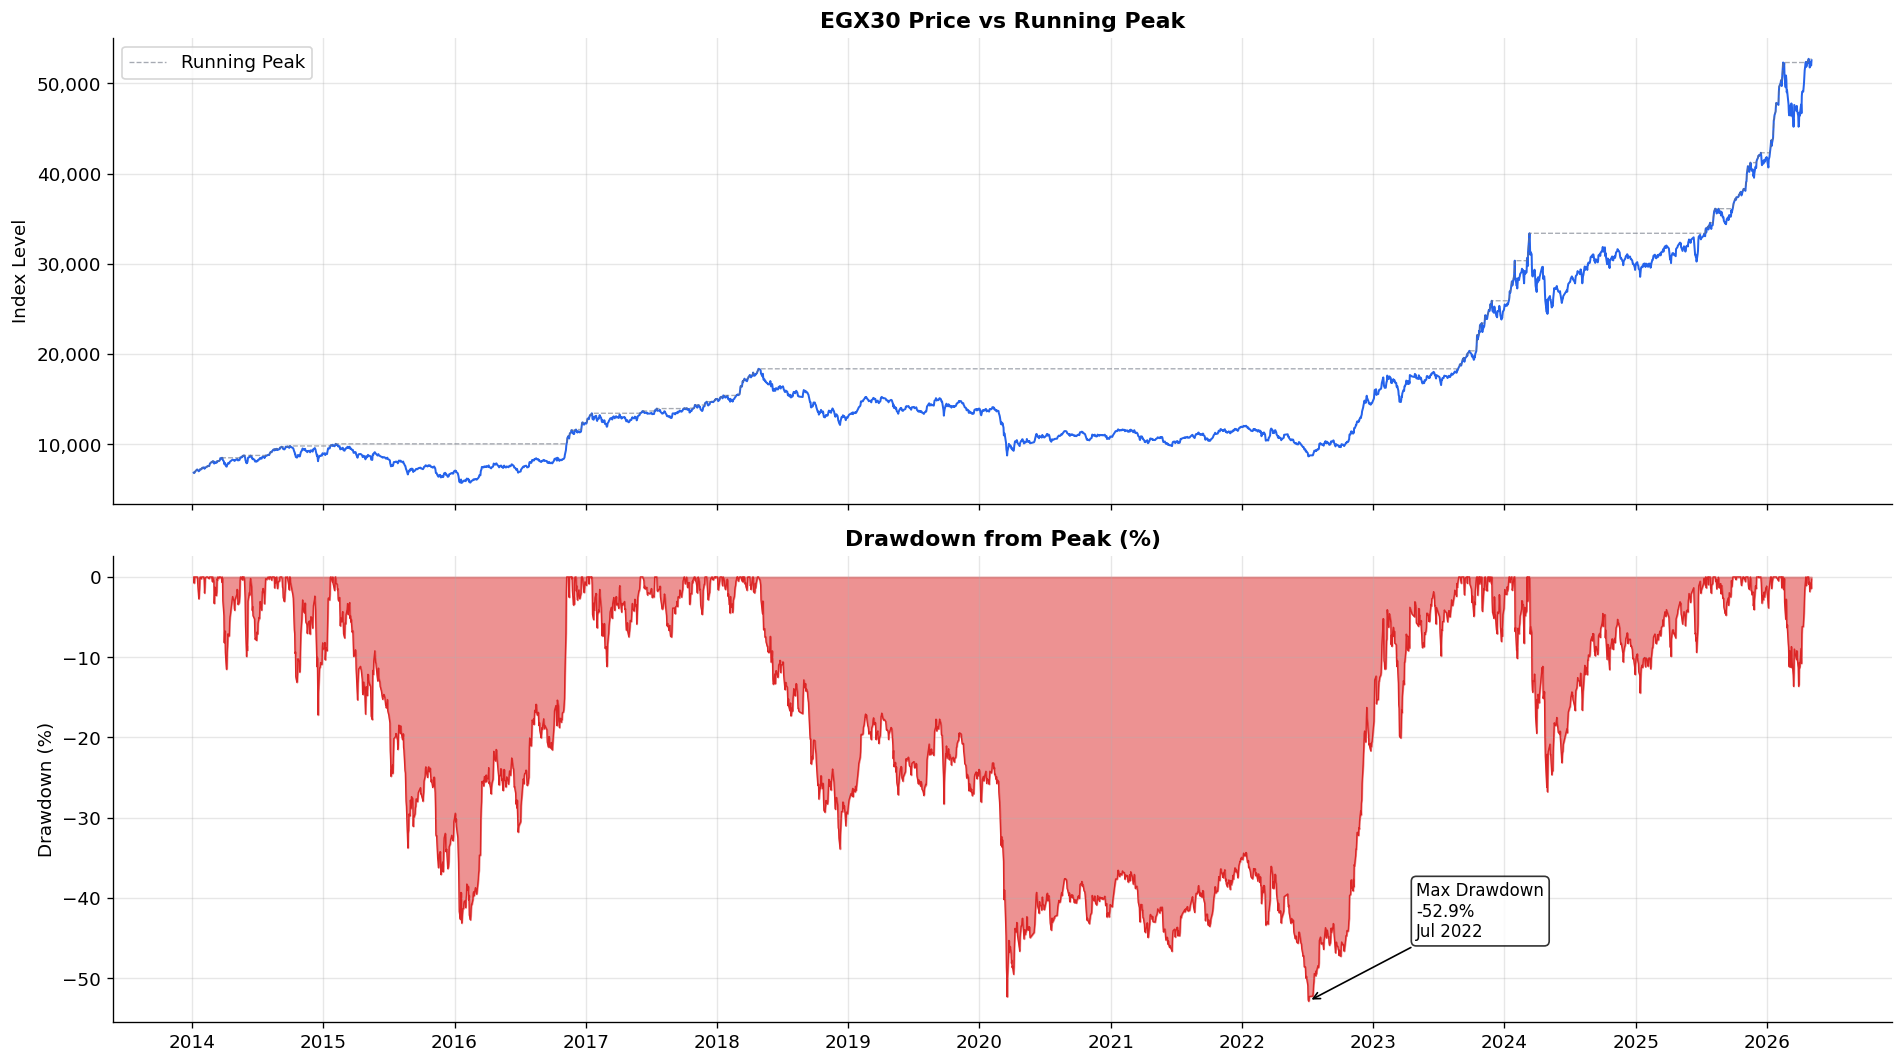

Maximum Drawdown: -52.85% on 2022-07-05


In [11]:
# Drawdown = how far the index has fallen from its running peak at any point
# Formula: (current price - running peak) / running peak
# Standard risk metric: tells us the worst loss an investor would have experienced
# if they bought at any peak and held to any subsequent trough

roll_max     = df['Close'].cummax()
df['Drawdown'] = (df['Close'] - roll_max) / roll_max * 100
max_dd       = df['Drawdown'].min()
max_dd_date  = df['Drawdown'].idxmin()

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

axes[0].plot(df.index, df['Close'], color=COLORS['blue'], linewidth=1.2)
axes[0].plot(df.index, roll_max, color=COLORS['gray'],
             linewidth=0.8, linestyle='--', alpha=0.6, label='Running Peak')
axes[0].set_title('EGX30 Price vs Running Peak', fontweight='bold')
axes[0].set_ylabel('Index Level')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].legend()

axes[1].fill_between(df.index, df['Drawdown'], 0,
                     color=COLORS['red'], alpha=0.5)
axes[1].plot(df.index, df['Drawdown'], color=COLORS['red'], linewidth=0.8)
axes[1].annotate(
    f'Max Drawdown\n{max_dd:.1f}%\n{max_dd_date.strftime("%b %Y")}',
    xy=(max_dd_date, max_dd),
    xytext=(max_dd_date + pd.DateOffset(days=300), max_dd + 8),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10, bbox=dict(boxstyle='round', fc='white', alpha=0.8)
)
axes[1].set_title('Drawdown from Peak (%)', fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('04_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Maximum Drawdown: {max_dd:.2f}% on {max_dd_date.date()}')

### 5.5 — Volume Analysis

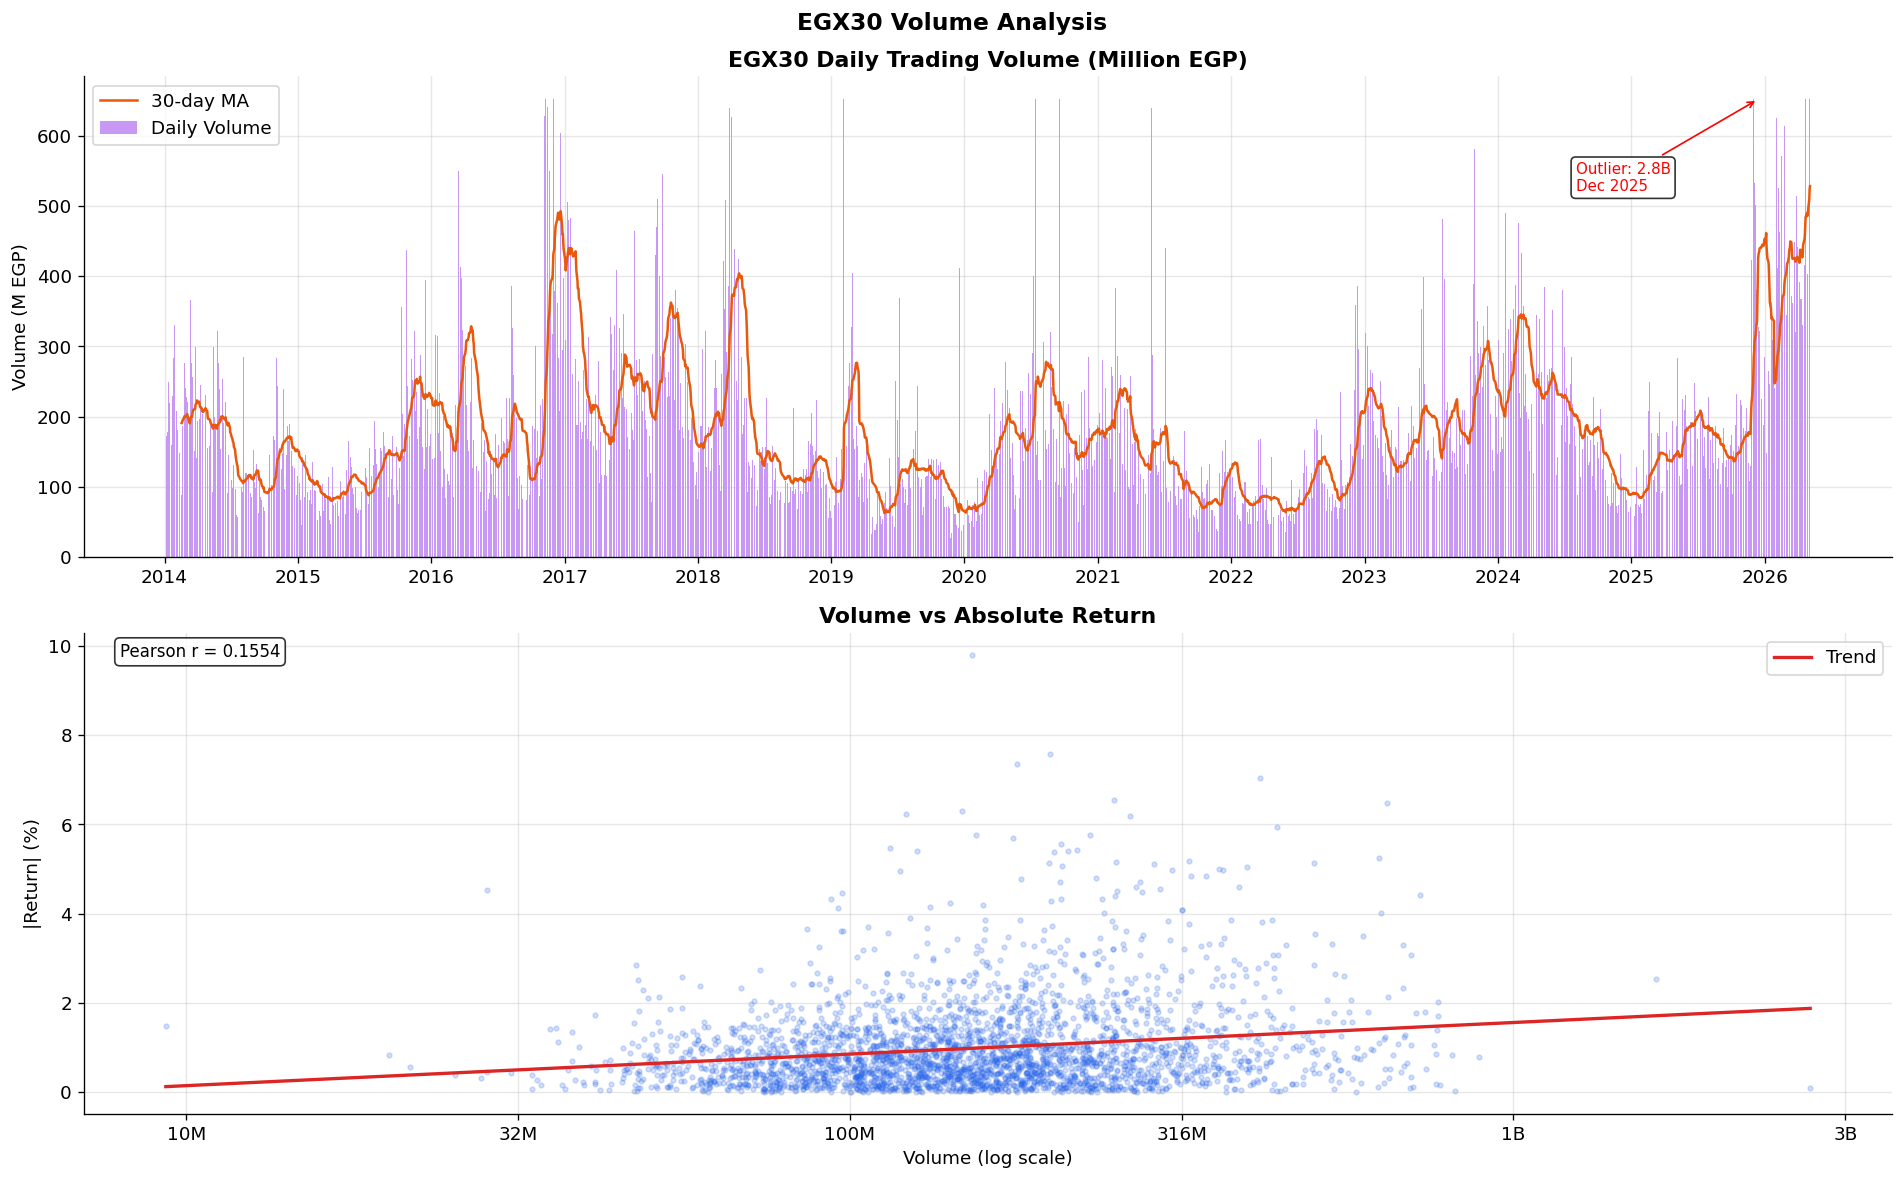

Volume-|Return| correlation: 0.1554


In [12]:
# Volume is capped at the 99th percentile for display only
# One extreme outlier (Dec 2025: 2.8B EGP) distorts the y-axis otherwise
# We annotate it on the chart rather than silently hiding it
# Log scale on x-axis for scatter: volume spans 2 orders of magnitude (10M to 3B)
# Linear scale would compress all points to the left making the scatter unreadable

df['Vol_MA30'] = df['Volume'].rolling(30).mean()
vol_cap      = df['Volume'].quantile(0.99)
vol_display  = df['Volume'].clip(upper=vol_cap)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].bar(df.index, vol_display/1e6,
            color=COLORS['purple'], alpha=0.5, width=1, label='Daily Volume')
axes[0].plot(df.index, df['Vol_MA30']/1e6,
             color=COLORS['orange'], linewidth=1.5, label='30-day MA')
axes[0].set_title('EGX30 Daily Trading Volume (Million EGP)', fontweight='bold')
axes[0].set_ylabel('Volume (M EGP)')
axes[0].legend()
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

outlier_date = df['Volume'].idxmax()
outlier_val  = df['Volume'].max()
axes[0].annotate(
    f'Outlier: {outlier_val/1e9:.1f}B\n{outlier_date.strftime("%b %Y")}',
    xy=(outlier_date, vol_cap/1e6),
    xytext=(outlier_date - pd.DateOffset(days=500), vol_cap*0.8/1e6),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=9, color='red',
    bbox=dict(boxstyle='round', fc='white', alpha=0.8)
)

log_vol = np.log10(df['Volume'])
abs_ret = df['Log_Return'].abs() * 100
axes[1].scatter(log_vol, abs_ret, alpha=0.2, color=COLORS['blue'], s=8)
z = np.polyfit(log_vol, abs_ret, 1)
xline = np.linspace(log_vol.min(), log_vol.max(), 100)
axes[1].plot(xline, np.poly1d(z)(xline),
             color=COLORS['red'], linewidth=2, label='Trend')
tick_vals   = [7, 7.5, 8, 8.5, 9, 9.5]
tick_labels = ['10M','32M','100M','316M','1B','3B']
axes[1].set_xticks(tick_vals)
axes[1].set_xticklabels(tick_labels)
axes[1].set_title('Volume vs Absolute Return', fontweight='bold')
axes[1].set_xlabel('Volume (log scale)')
axes[1].set_ylabel('|Return| (%)')
axes[1].legend()
corr = df['Volume'].corr(df['Log_Return'].abs())
axes[1].text(0.02, 0.95, f'Pearson r = {corr:.4f}',
             transform=axes[1].transAxes, fontsize=10,
             bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.suptitle('EGX30 Volume Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Volume-|Return| correlation: {corr:.4f}')

### 5.6 — Autocorrelation of Returns & Squared Returns

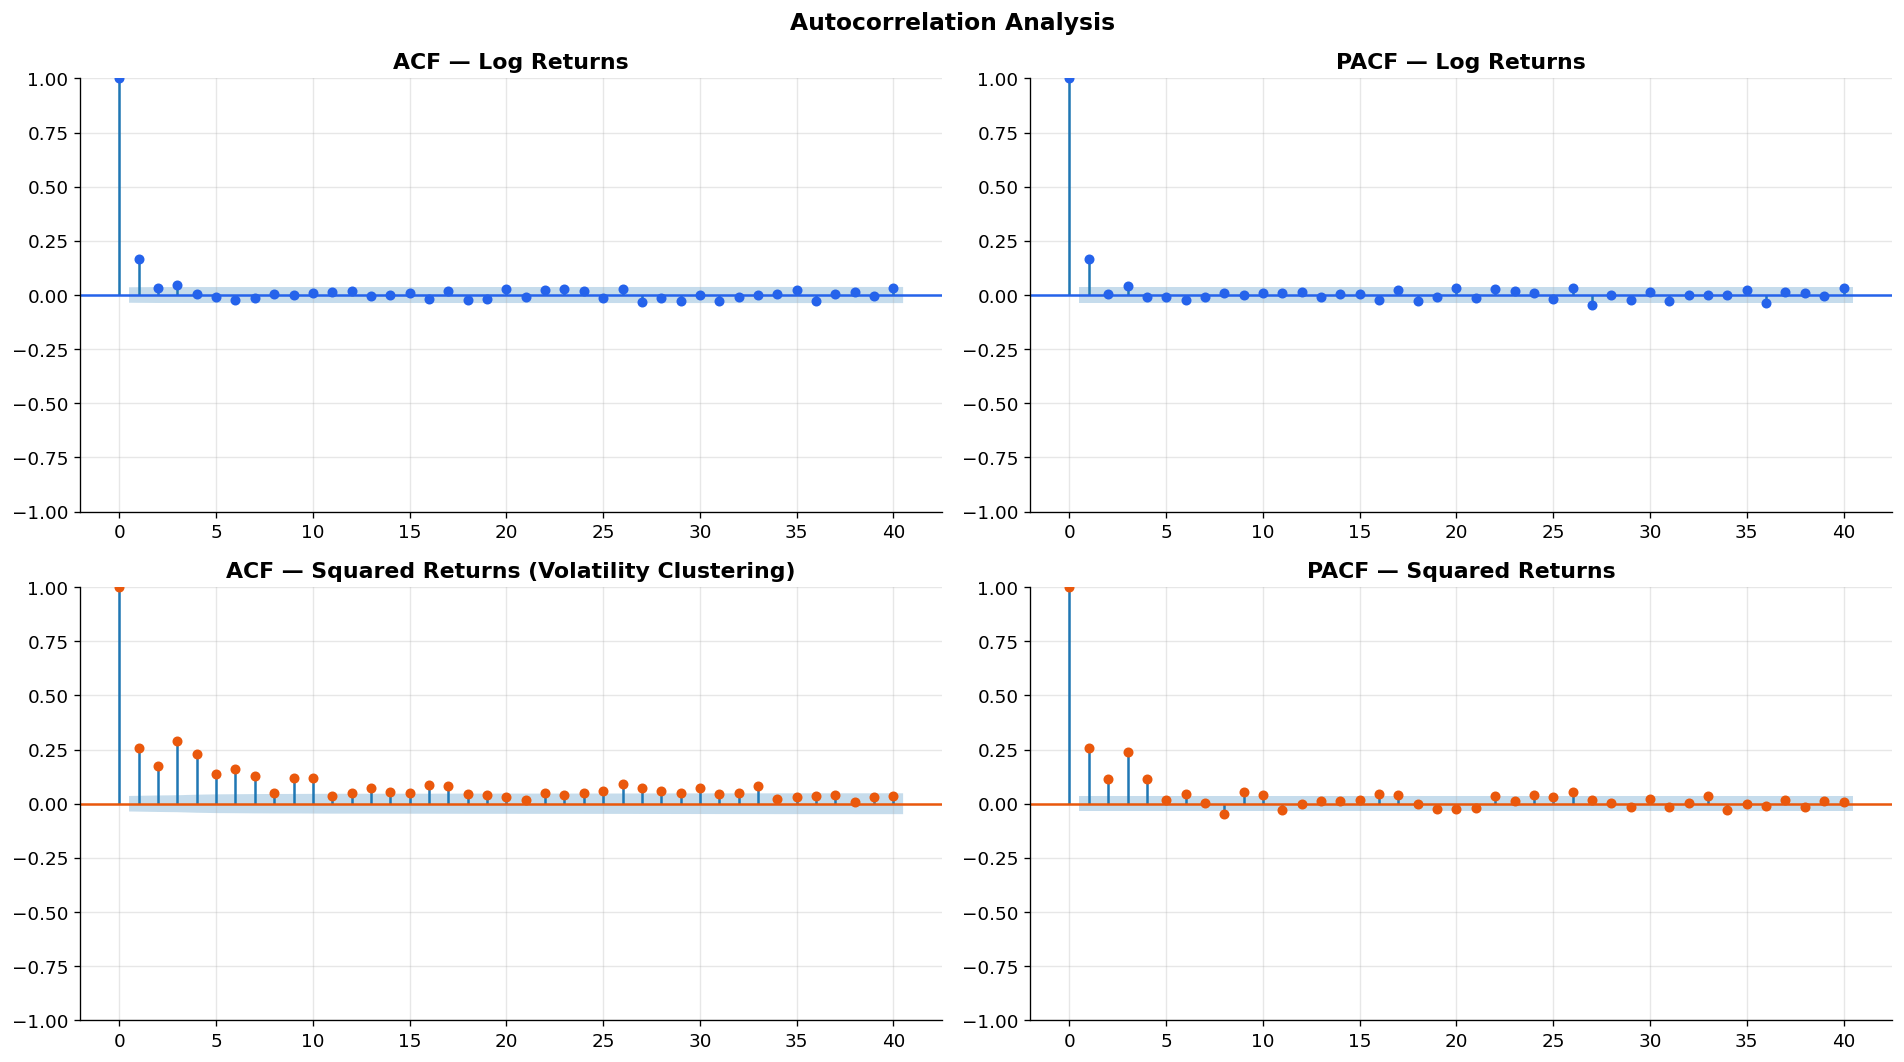

Returns: little autocorrelation → market near weak-form efficient
Squared returns: strong autocorrelation → volatility clustering confirmed


In [13]:
# ACF: correlation of the series with its own lagged values
# PACF: correlation at each lag after removing the effect of shorter lags
# Returns with near-zero ACF → no linear predictability → efficient market
# Squared returns with strong ACF → volatility clusters (large moves follow large moves)
# This is the statistical signature of ARCH/GARCH effects in financial data

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

plot_acf(df['Log_Return'].dropna(),    lags=40, ax=axes[0,0], color=COLORS['blue'])
axes[0,0].set_title('ACF — Log Returns', fontweight='bold')

plot_pacf(df['Log_Return'].dropna(),   lags=40, ax=axes[0,1], color=COLORS['blue'])
axes[0,1].set_title('PACF — Log Returns', fontweight='bold')

plot_acf(df['Log_Return'].dropna()**2, lags=40, ax=axes[1,0], color=COLORS['orange'])
axes[1,0].set_title('ACF — Squared Returns (Volatility Clustering)', fontweight='bold')

plot_pacf(df['Log_Return'].dropna()**2,lags=40, ax=axes[1,1], color=COLORS['orange'])
axes[1,1].set_title('PACF — Squared Returns', fontweight='bold')

plt.suptitle('Autocorrelation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Returns: little autocorrelation → market near weak-form efficient')
print('Squared returns: strong autocorrelation → volatility clustering confirmed')

### 5.7 — Calendar Effects (Day-of-Week & Monthly)

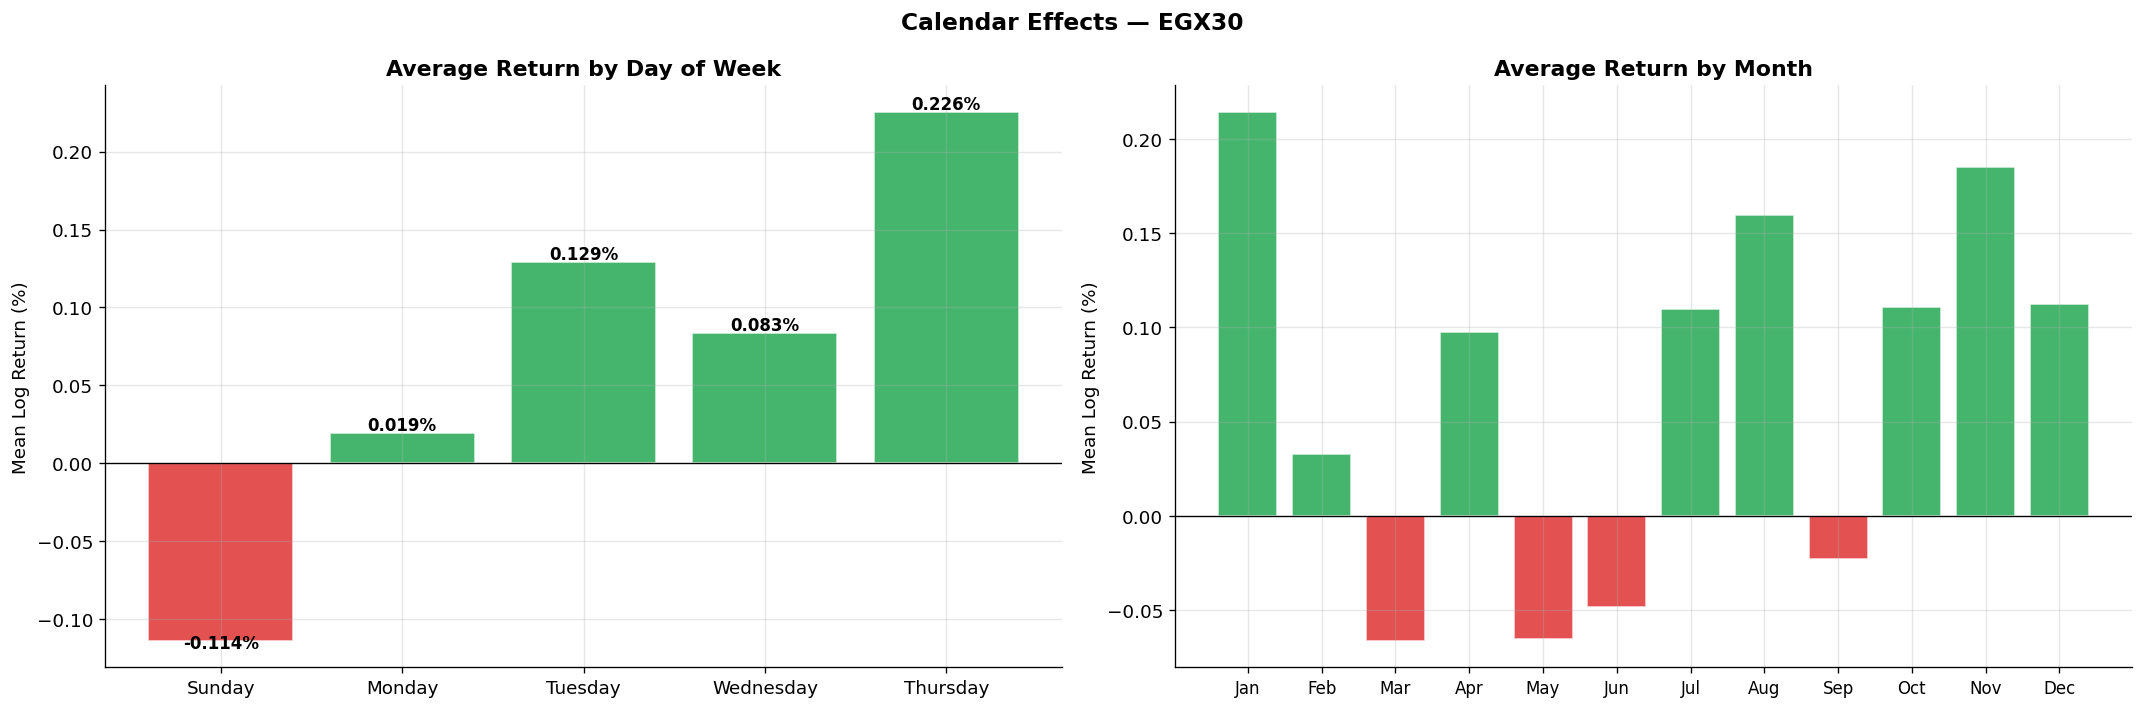

In [14]:
# EGX trading days are Sun-Thu (Egyptian market calendar)
# groupby + mean reveals if any day systematically outperforms others

df['DayOfWeek']  = df.index.day_name()
df['MonthName']  = df.index.month_name()
df['Year']       = df.index.year

day_order   = ['Sunday','Monday','Tuesday','Wednesday','Thursday']
month_order = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

day_ret = df.groupby('DayOfWeek')['Log_Return'].mean() * 100
day_ret = day_ret.reindex([d for d in day_order if d in day_ret.index])
colors_dow = [COLORS['green'] if v >= 0 else COLORS['red'] for v in day_ret.values]
axes[0].bar(day_ret.index, day_ret.values,
            color=colors_dow, alpha=0.8, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Average Return by Day of Week', fontweight='bold')
axes[0].set_ylabel('Mean Log Return (%)')
for i, v in enumerate(day_ret.values):
    axes[0].text(i, v + (0.002 if v >= 0 else -0.005),
                 f'{v:.3f}%', ha='center', fontsize=10, fontweight='bold')

month_ret = df.groupby('MonthName')['Log_Return'].mean() * 100
month_ret = month_ret.reindex([m for m in month_order if m in month_ret.index])
colors_mo = [COLORS['green'] if v >= 0 else COLORS['red'] for v in month_ret.values]
axes[1].bar(range(len(month_ret)), month_ret.values,
            color=colors_mo, alpha=0.8, edgecolor='white')
axes[1].set_xticks(range(len(month_ret)))
axes[1].set_xticklabels([m[:3] for m in month_ret.index], fontsize=10)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Average Return by Month', fontweight='bold')
axes[1].set_ylabel('Mean Log Return (%)')

plt.suptitle('Calendar Effects — EGX30', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_calendar_effects.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.8 — Ramadan Effect

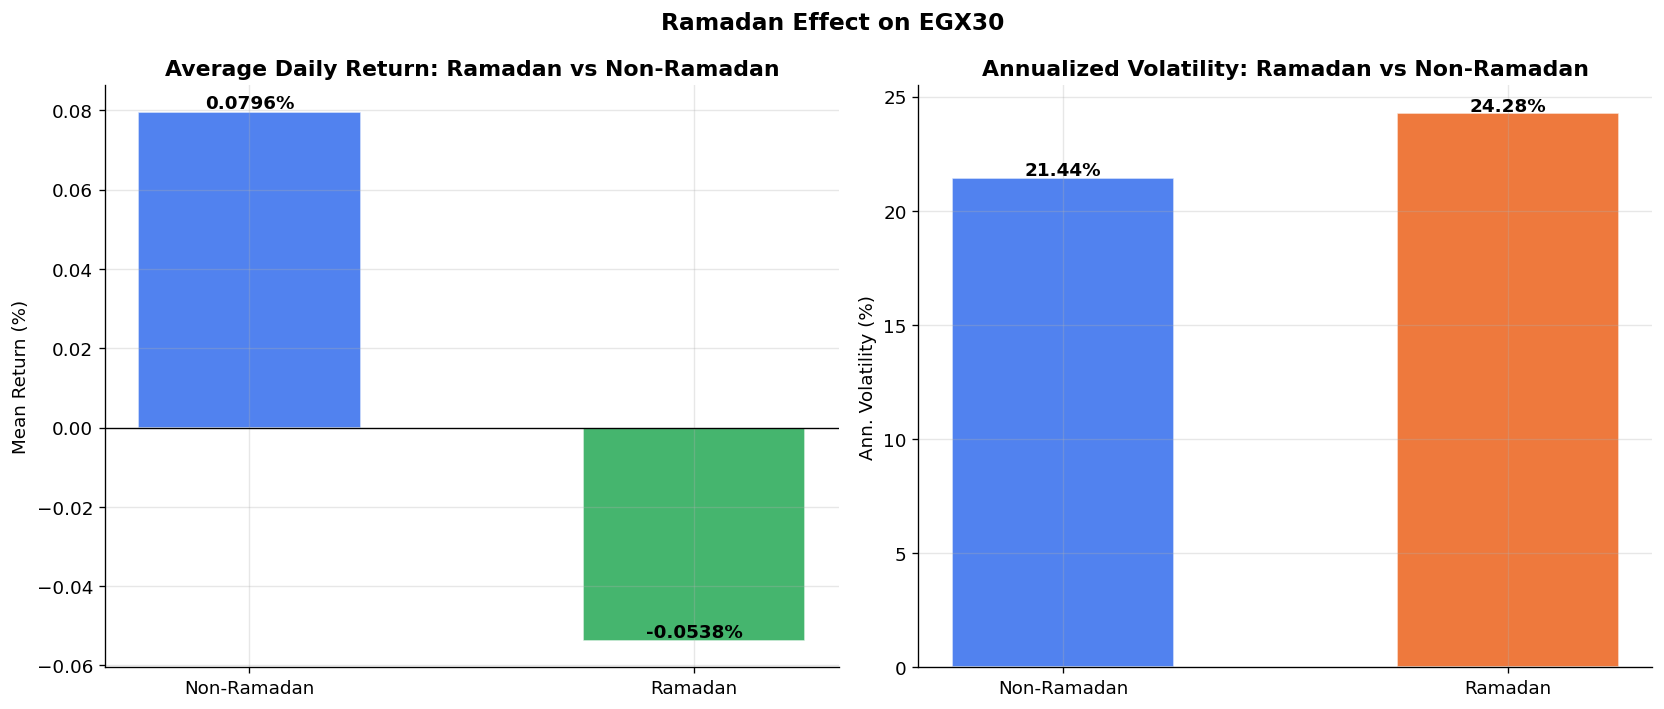

             mean_pct    ann_vol  count
Non-Ramadan  0.079632  21.444108   2741
Ramadan     -0.053818  24.278446    259


In [15]:
# Ramadan dates shift ~11 days earlier each year (lunar calendar)
# We manually define each year range for accuracy
# Hypothesis: reduced trading hours and behavioral changes during Ramadan
# may affect market returns and volatility

ramadan_periods = [
    ('2014-06-28','2014-07-27'), ('2015-06-18','2015-07-17'),
    ('2016-06-06','2016-07-05'), ('2017-05-27','2017-06-24'),
    ('2018-05-16','2018-06-14'), ('2019-05-05','2019-06-03'),
    ('2020-04-23','2020-05-23'), ('2021-04-13','2021-05-12'),
    ('2022-04-02','2022-05-01'), ('2023-03-23','2023-04-21'),
    ('2024-03-11','2024-04-09'), ('2025-03-01','2025-03-30'),
    ('2026-02-18','2026-03-19'),
]
df['IsRamadan'] = False
for start, end in ramadan_periods:
    df.loc[start:end, 'IsRamadan'] = True

ramadan_ret = df.groupby('IsRamadan')['Log_Return'].agg(['mean','std','count'])
ramadan_ret.index = ['Non-Ramadan','Ramadan']
ramadan_ret['mean_pct'] = ramadan_ret['mean'] * 100
ramadan_ret['ann_vol']  = ramadan_ret['std']  * np.sqrt(252) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(ramadan_ret.index, ramadan_ret['mean_pct'],
            color=[COLORS['blue'], COLORS['green']], alpha=0.8,
            edgecolor='white', width=0.5)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Average Daily Return: Ramadan vs Non-Ramadan', fontweight='bold')
axes[0].set_ylabel('Mean Return (%)')
for i, v in enumerate(ramadan_ret['mean_pct']):
    axes[0].text(i, v + 0.001, f'{v:.4f}%', ha='center', fontweight='bold')

axes[1].bar(ramadan_ret.index, ramadan_ret['ann_vol'],
            color=[COLORS['blue'], COLORS['orange']], alpha=0.8,
            edgecolor='white', width=0.5)
axes[1].set_title('Annualized Volatility: Ramadan vs Non-Ramadan', fontweight='bold')
axes[1].set_ylabel('Ann. Volatility (%)')
for i, v in enumerate(ramadan_ret['ann_vol']):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

plt.suptitle('Ramadan Effect on EGX30', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_ramadan_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print(ramadan_ret[['mean_pct','ann_vol','count']])

### 5.9 — Event Analysis: Major Economic Shocks

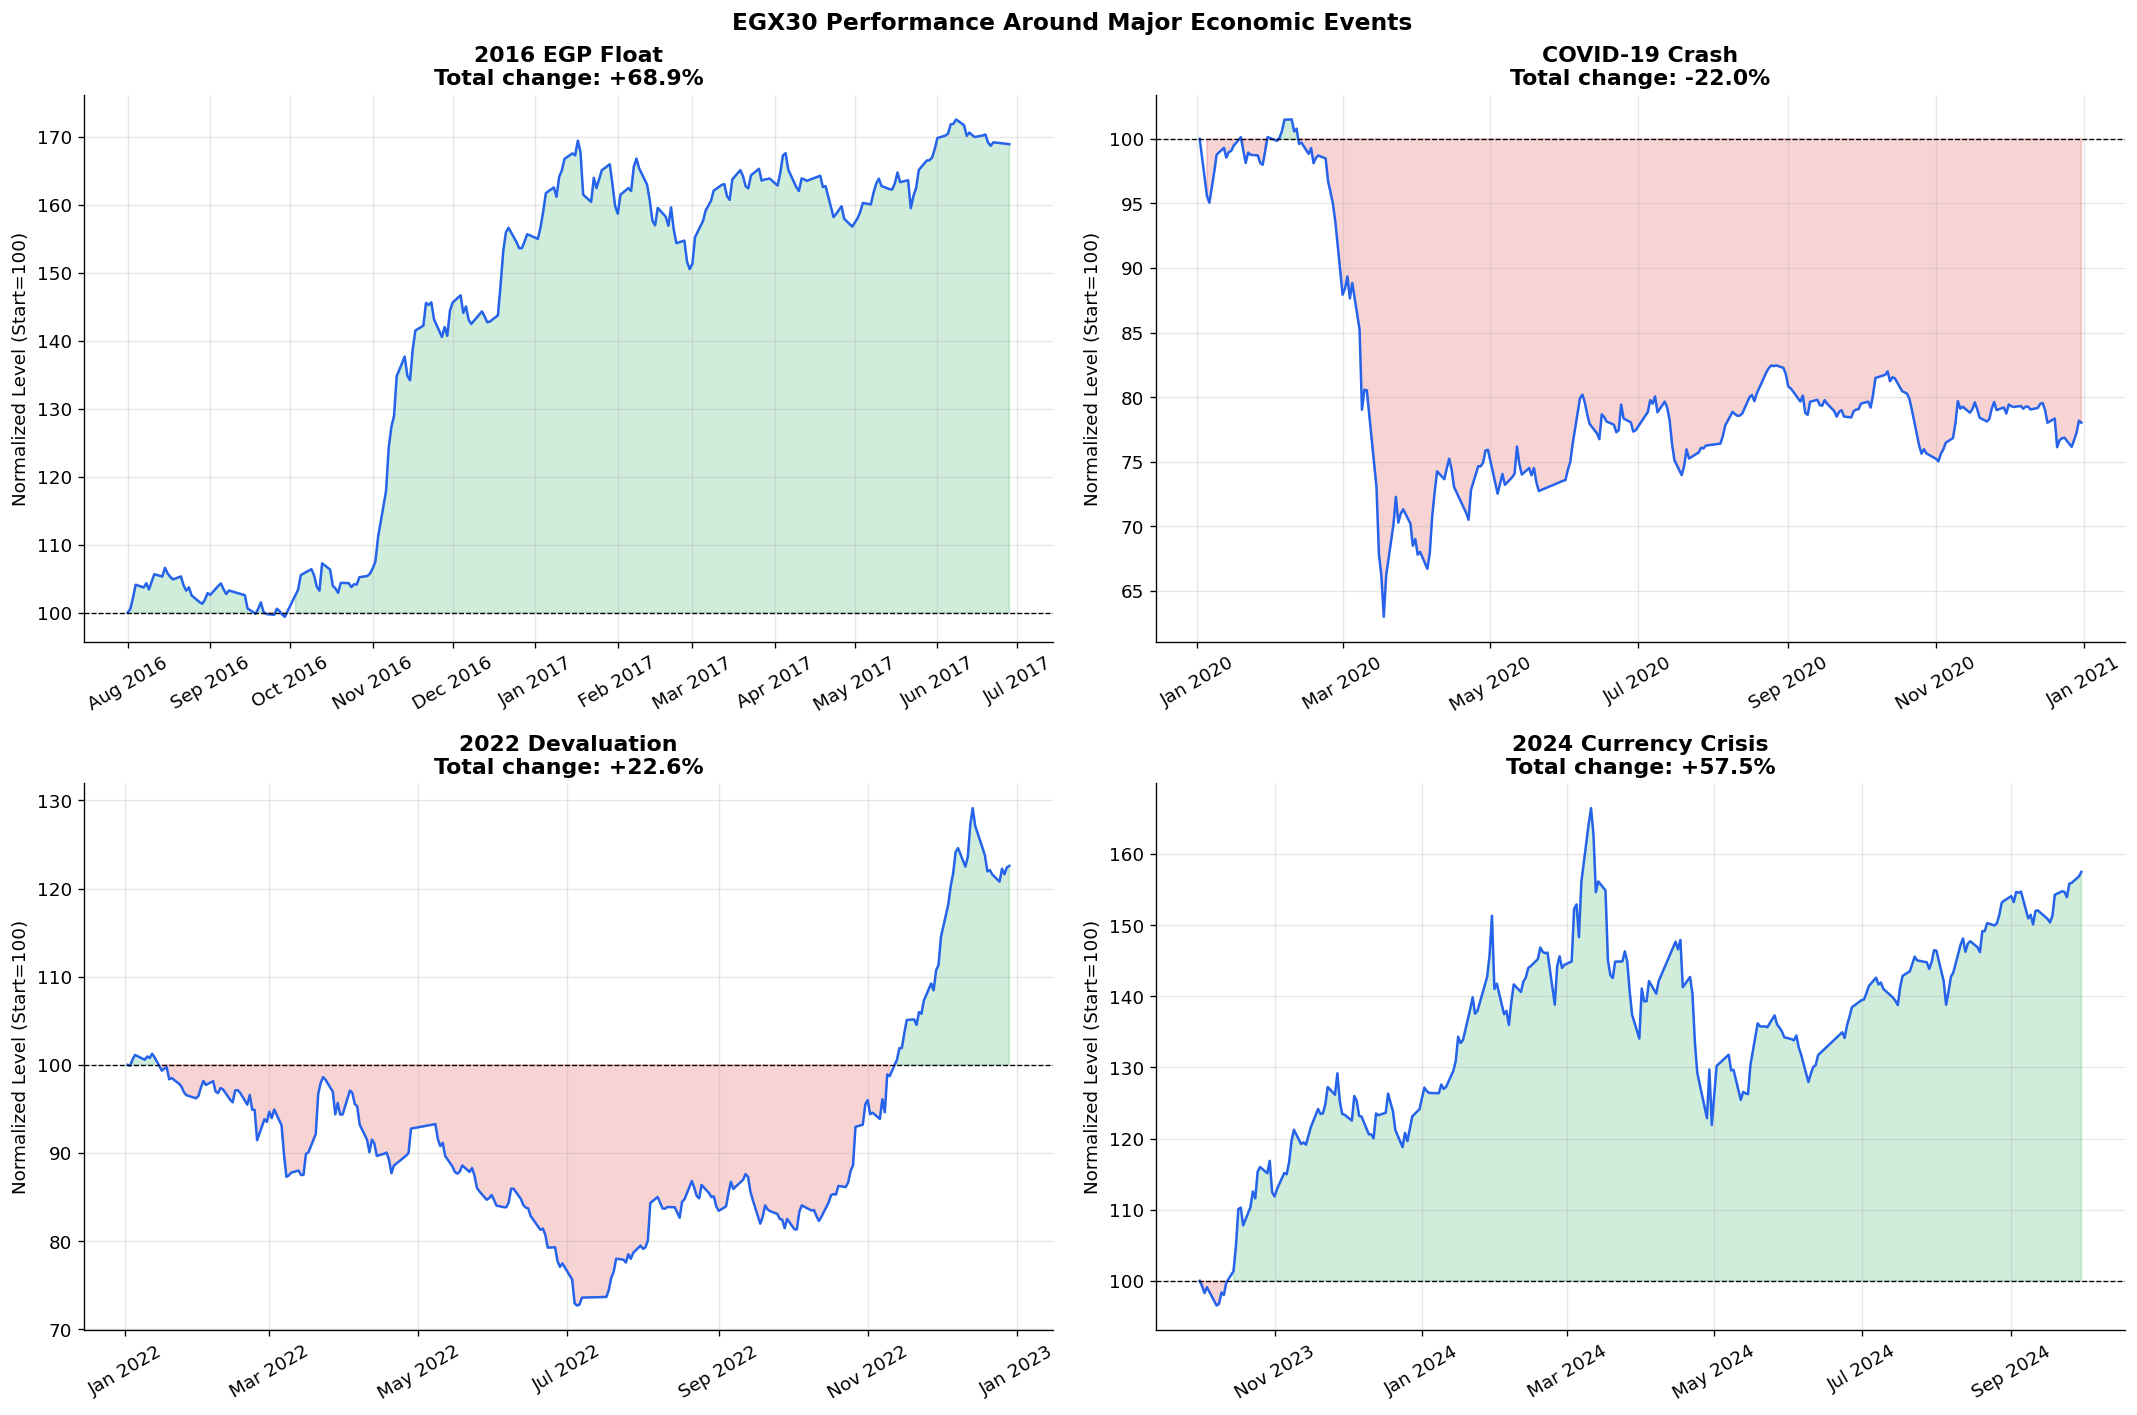

In [16]:
# Normalize each event window to 100 at its start date
# This lets us compare the magnitude and shape of each crisis response
# regardless of the absolute index level at the time

events_windows = {
    '2016 EGP Float':       ('2016-08-01','2017-06-30'),
    'COVID-19 Crash':        ('2020-01-01','2020-12-31'),
    '2022 Devaluation':      ('2022-01-01','2022-12-31'),
    '2024 Currency Crisis':  ('2023-10-01','2024-09-30'),
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, (event_name, (start, end)) in enumerate(events_windows.items()):
    segment      = df.loc[start:end, 'Close']
    segment_norm = segment / segment.iloc[0] * 100
    axes[idx].plot(segment_norm.index, segment_norm.values,
                   color=COLORS['blue'], linewidth=1.5)
    axes[idx].fill_between(segment_norm.index, segment_norm.values, 100,
                           where=segment_norm.values>=100,
                           alpha=0.2, color=COLORS['green'])
    axes[idx].fill_between(segment_norm.index, segment_norm.values, 100,
                           where=segment_norm.values<100,
                           alpha=0.2, color=COLORS['red'])
    axes[idx].axhline(100, color='black', linewidth=0.8, linestyle='--')
    total_chg = (segment.iloc[-1]/segment.iloc[0]-1)*100
    axes[idx].set_title(f'{event_name}\nTotal change: {total_chg:+.1f}%', fontweight='bold')
    axes[idx].set_ylabel('Normalized Level (Start=100)')
    axes[idx].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[idx].tick_params(axis='x', rotation=30)

plt.suptitle('EGX30 Performance Around Major Economic Events',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('09_event_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.10 — Risk Metrics & Annual Returns

       EGX30 RISK METRICS SUMMARY
Annualized Return     :      17.16%
Annualized Volatility :      21.71%
Sharpe Ratio (RF=15.06%) :     0.0969
Max Drawdown          :     -52.85%
VaR 95% (daily)       :      -2.01%
VaR 99% (daily)       :      -4.12%
CVaR 95% (daily)      :      -3.27%


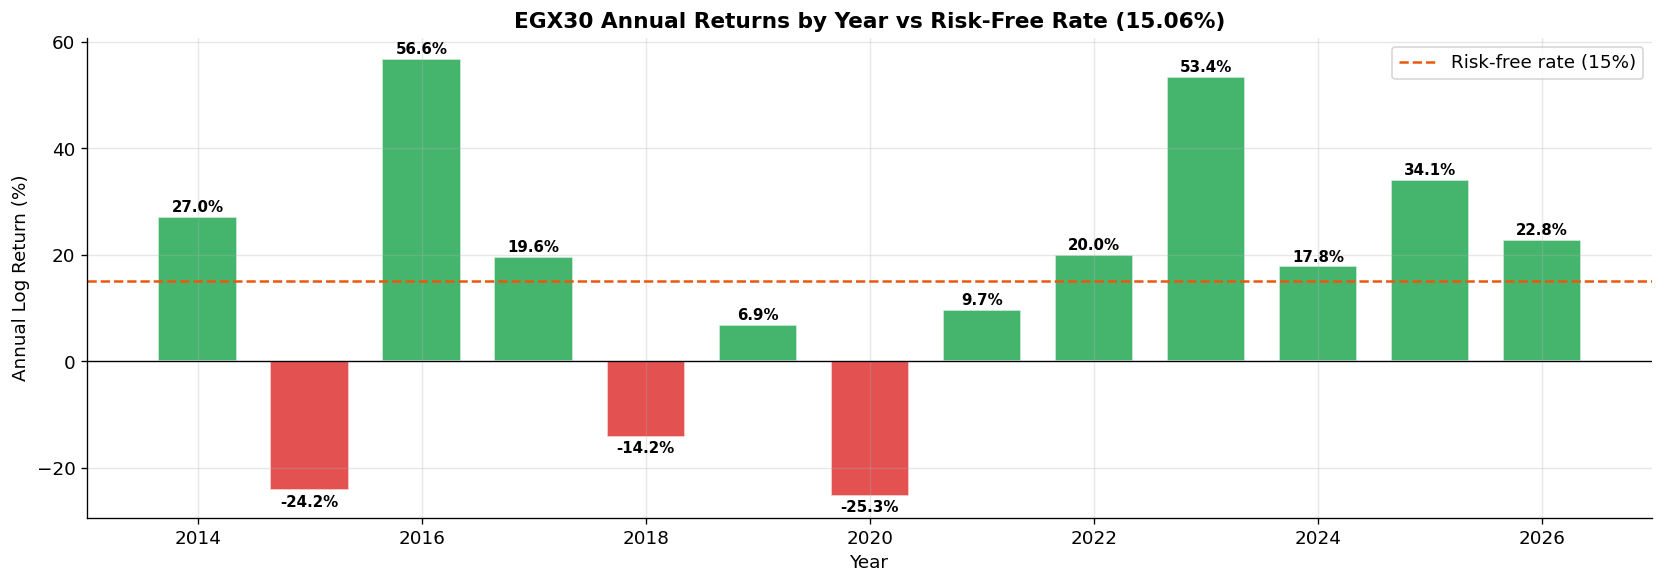

In [17]:
# Sharpe ratio: risk-adjusted return above the risk-free rate
# RF = 15.06% (Egyptian T-bill rate, approx average over analysis period)
# Sharpe > 0 means EGX30 marginally outperformed T-bills on a risk-adjusted basis
# however the premium is near-zero (+0.10), meaning the return barely compensated
# investors for the volatility and drawdown risk taken
# relative to simply holding T-bills — an honest and important finding
# VaR: the loss threshold we expect NOT to breach on X% of trading days
# CVaR (Expected Shortfall): average loss on days WORSE than VaR threshold
# CVaR is more informative than VaR because it describes the tail, not just its cutoff

annual_ret  = df['Log_Return'].mean()  * 252  * 100
annual_vol  = df['Log_Return'].std()   * np.sqrt(252) * 100
RF_ANNUAL = 15.06  # Average CBE overnight deposit rate 2014-2025
sharpe      = (annual_ret - RF_ANNUAL) / annual_vol
max_dd_val  = df['Drawdown'].min()
var_95      = np.percentile(df['Log_Return'], 5)  * 100
var_99      = np.percentile(df['Log_Return'], 1)  * 100
cvar_95     = df['Log_Return'][df['Log_Return'] <= np.percentile(df['Log_Return'],5)].mean() * 100

print('='*45)
print('       EGX30 RISK METRICS SUMMARY')
print('='*45)
print(f'Annualized Return     : {annual_ret:>10.2f}%')
print(f'Annualized Volatility : {annual_vol:>10.2f}%')
print(f'Sharpe Ratio (RF=15.06%) : {sharpe:>10.4f}')
print(f'Max Drawdown          : {max_dd_val:>10.2f}%')
print(f'VaR 95% (daily)       : {var_95:>10.2f}%')
print(f'VaR 99% (daily)       : {var_99:>10.2f}%')
print(f'CVaR 95% (daily)      : {cvar_95:>10.2f}%')
print('='*45)

yearly = df['Log_Return'].resample('YE').sum() * 100
yearly.index = yearly.index.year

fig, ax = plt.subplots(figsize=(14, 5))
colors_yr = [COLORS['green'] if v >= 0 else COLORS['red'] for v in yearly.values]
bars = ax.bar(yearly.index, yearly.values,
              color=colors_yr, alpha=0.8, edgecolor='white', width=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(RF_ANNUAL, color=COLORS['orange'], linewidth=1.5,
           linestyle='--', label=f'Risk-free rate ({RF_ANNUAL:.0f}%)')
for bar, val in zip(bars, yearly.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            val+(1 if val>=0 else -3),
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('EGX30 Annual Returns by Year vs Risk-Free Rate (15.06%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Annual Log Return (%)')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.savefig('10_annual_returns.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔧 PHASE 6 — Feature Engineering & Technical Indicators

In [18]:
# SMA: equal weight to all days in window — simple, more lagged
# EMA: exponentially more weight to recent days — reacts faster to price changes
# RSI > 70 = overbought (potential reversal down), RSI < 30 = oversold (potential reversal up)
# MACD = 12-day EMA minus 26-day EMA — captures trend momentum and direction changes
# Bollinger Bands: price envelope at ±2 std devs around 20-day SMA
# BB_Width expands during high volatility, contracts during low
# ATR (Average True Range): volatility measure using full price range including overnight gaps
# dropna() removes rows where rolling windows do not yet have enough data (first ~200 rows)

dff = df.copy()

# Moving Averages
for w in [7, 20, 50, 200]:
    dff[f'SMA_{w}'] = dff['Close'].rolling(w).mean()
    dff[f'EMA_{w}'] = dff['Close'].ewm(span=w, adjust=False).mean()

# RSI
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    return 100 - (100 / (1 + gain/loss))
dff['RSI_14'] = compute_rsi(dff['Close'])

# MACD
ema12 = dff['Close'].ewm(span=12, adjust=False).mean()
ema26 = dff['Close'].ewm(span=26, adjust=False).mean()
dff['MACD']        = ema12 - ema26
dff['MACD_Signal'] = dff['MACD'].ewm(span=9, adjust=False).mean()
dff['MACD_Hist']   = dff['MACD'] - dff['MACD_Signal']

# Bollinger Bands
bb_mid = dff['Close'].rolling(20).mean()
bb_std = dff['Close'].rolling(20).std()
dff['BB_Upper'] = bb_mid + 2*bb_std
dff['BB_Lower'] = bb_mid - 2*bb_std
dff['BB_Width'] = (dff['BB_Upper'] - dff['BB_Lower']) / bb_mid
dff['BB_Pct']   = (dff['Close'] - dff['BB_Lower']) / (dff['BB_Upper'] - dff['BB_Lower'])

# ATR
tr = pd.concat([
    dff['High'] - dff['Low'],
    (dff['High'] - dff['Close'].shift()).abs(),
    (dff['Low']  - dff['Close'].shift()).abs()
], axis=1).max(axis=1)
dff['ATR_14'] = tr.rolling(14).mean()

dff = dff.dropna()
print(f'Features created. Shape: {dff.shape}')

Features created. Shape: (2801, 33)


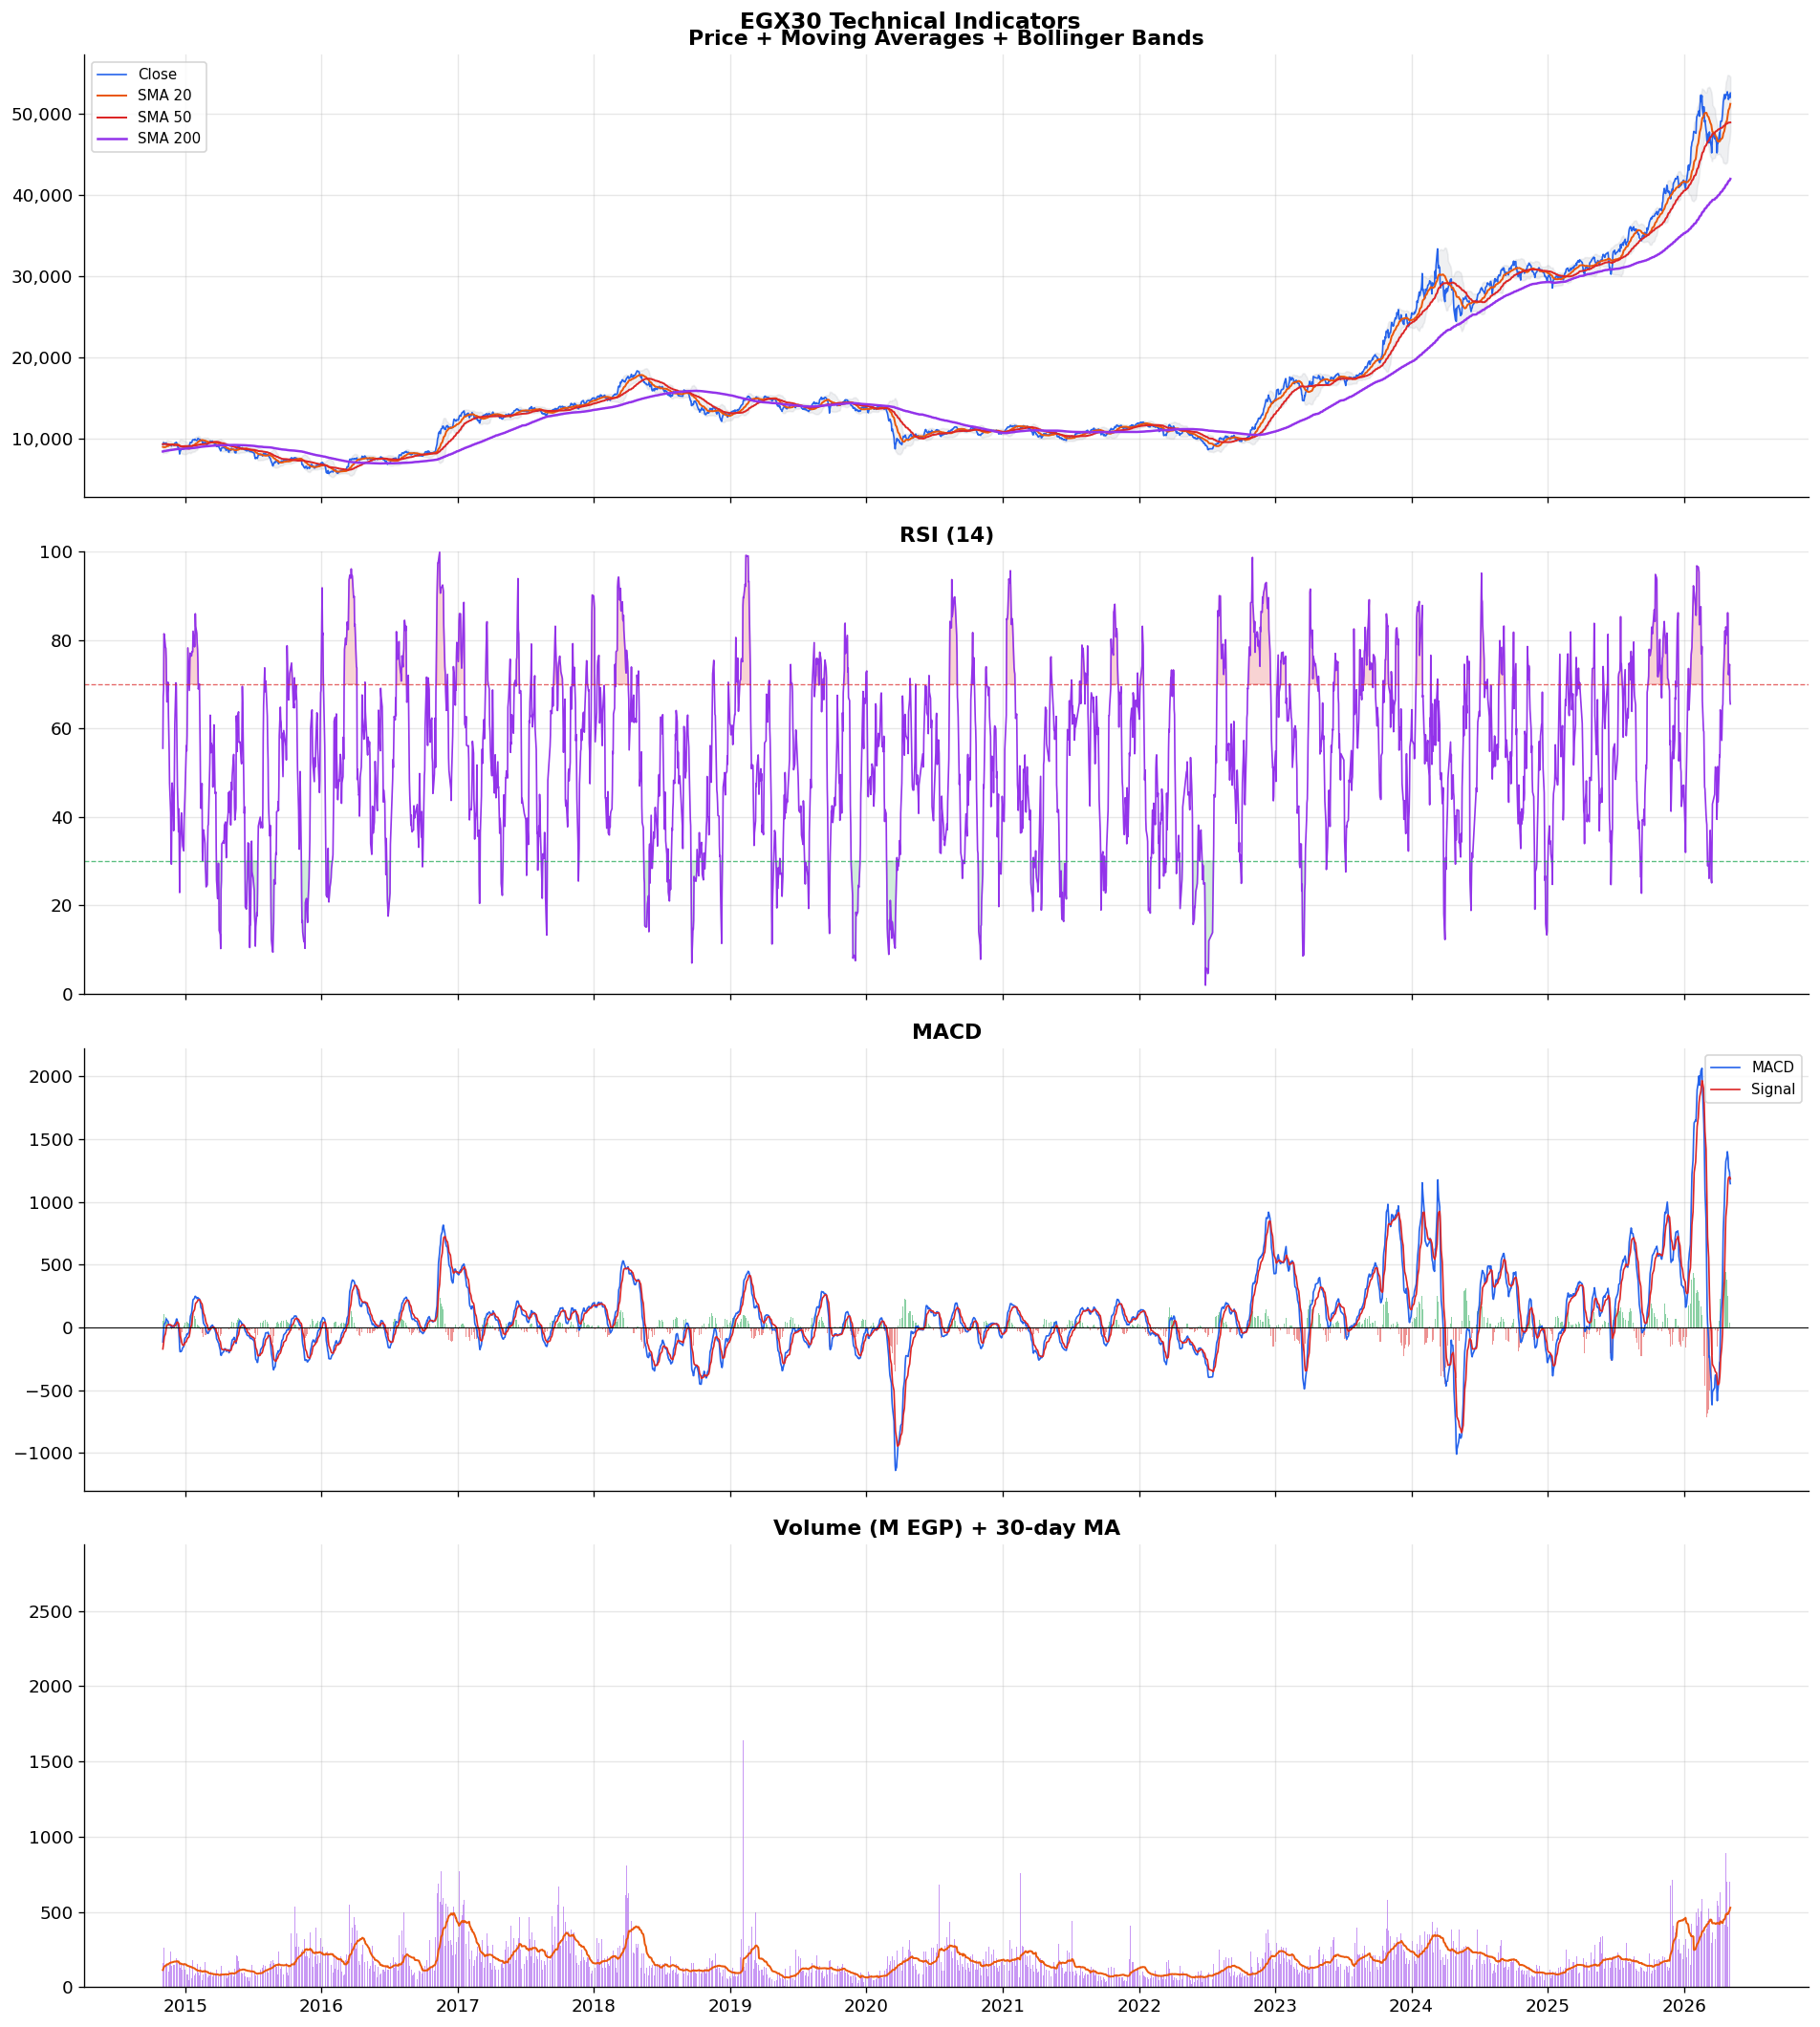

In [19]:
fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)

# Price + MAs + Bollinger
axes[0].plot(dff.index, dff['Close'],   color=COLORS['blue'],   linewidth=1,   label='Close')
axes[0].plot(dff.index, dff['SMA_20'],  color=COLORS['orange'], linewidth=1.2, label='SMA 20')
axes[0].plot(dff.index, dff['SMA_50'],  color=COLORS['red'],    linewidth=1.2, label='SMA 50')
axes[0].plot(dff.index, dff['SMA_200'], color=COLORS['purple'], linewidth=1.5, label='SMA 200')
axes[0].fill_between(dff.index, dff['BB_Upper'], dff['BB_Lower'],
                     alpha=0.1, color=COLORS['gray'])
axes[0].set_title('Price + Moving Averages + Bollinger Bands', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].legend(fontsize=9)

# RSI
axes[1].plot(dff.index, dff['RSI_14'], color=COLORS['purple'], linewidth=1)
axes[1].axhline(70, color=COLORS['red'],   linestyle='--', linewidth=0.8, alpha=0.7)
axes[1].axhline(30, color=COLORS['green'], linestyle='--', linewidth=0.8, alpha=0.7)
axes[1].fill_between(dff.index, dff['RSI_14'], 70,
                     where=dff['RSI_14']>=70, alpha=0.2, color=COLORS['red'])
axes[1].fill_between(dff.index, dff['RSI_14'], 30,
                     where=dff['RSI_14']<=30, alpha=0.2, color=COLORS['green'])
axes[1].set_title('RSI (14)', fontweight='bold')
axes[1].set_ylim(0, 100)

# MACD
axes[2].plot(dff.index, dff['MACD'],        color=COLORS['blue'], linewidth=1,   label='MACD')
axes[2].plot(dff.index, dff['MACD_Signal'], color=COLORS['red'],  linewidth=1,   label='Signal')
axes[2].bar(dff.index, dff['MACD_Hist'],
            color=[COLORS['green'] if v>=0 else COLORS['red'] for v in dff['MACD_Hist']],
            alpha=0.5, width=1)
axes[2].axhline(0, color='black', linewidth=0.6)
axes[2].set_title('MACD', fontweight='bold')
axes[2].legend(fontsize=9)

# Volume
axes[3].bar(dff.index, dff['Volume']/1e6,
            color=COLORS['purple'], alpha=0.5, width=1)
axes[3].plot(dff.index, dff['Vol_MA30']/1e6,
             color=COLORS['orange'], linewidth=1.2)
axes[3].set_title('Volume (M EGP) + 30-day MA', fontweight='bold')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('EGX30 Technical Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('11_technical_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

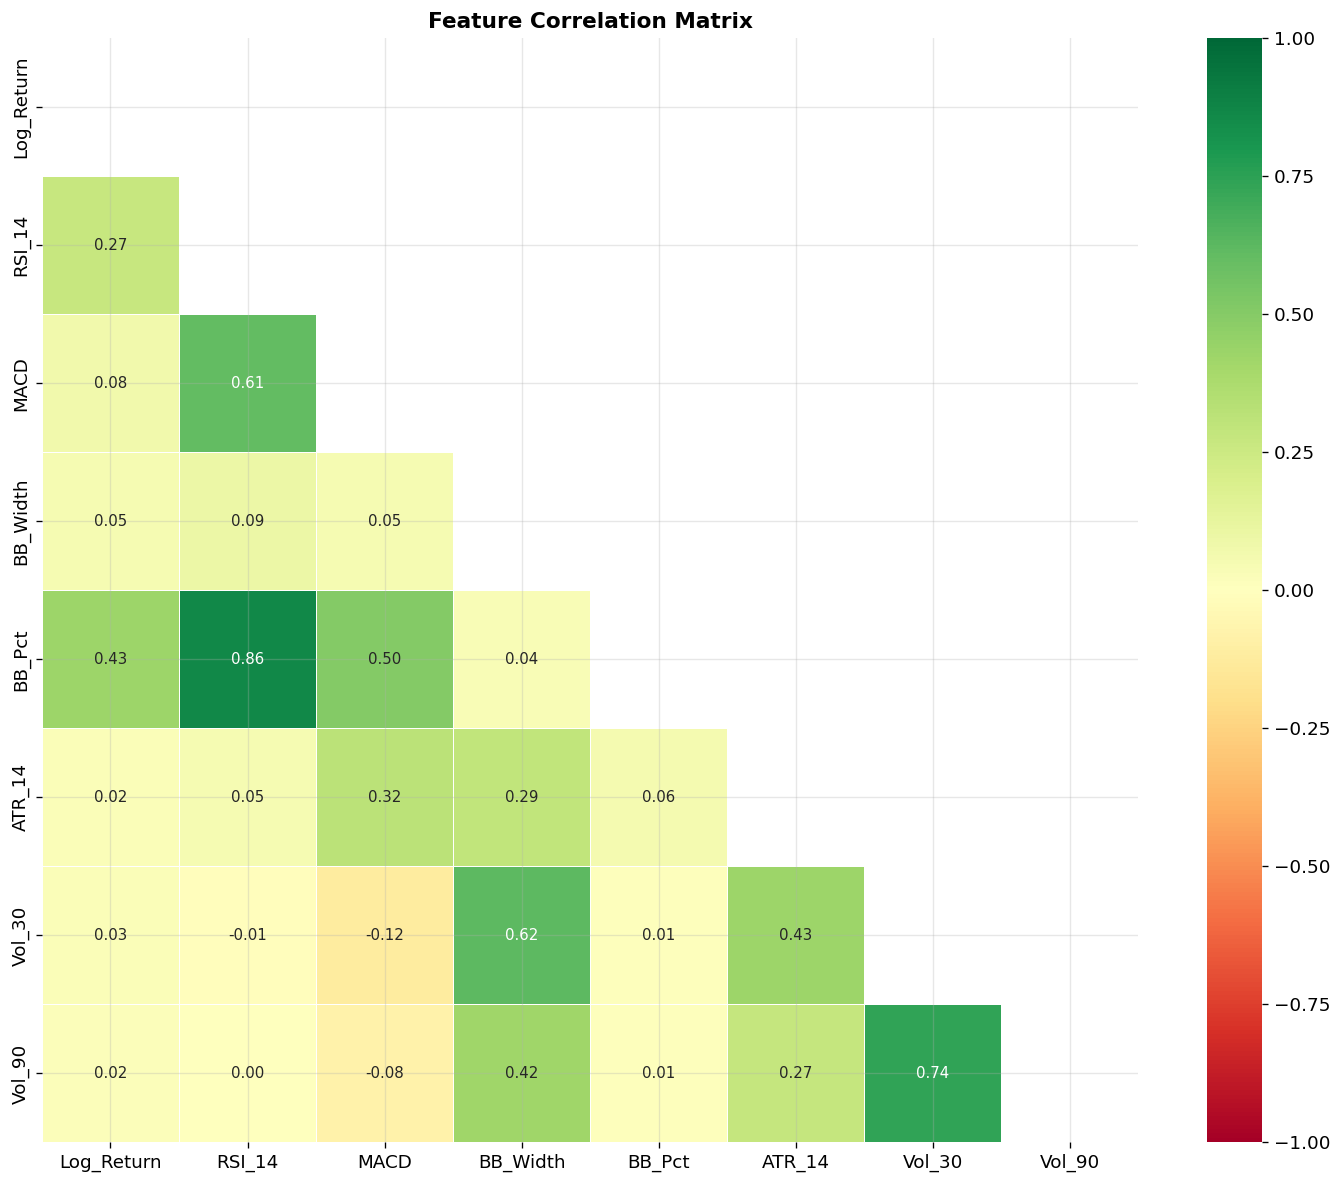

In [20]:
# Correlation heatmap reveals which features move together
# High correlation between features = redundancy, can cause multicollinearity in models
# Lower triangular mask avoids duplicate information

feature_cols = ['Log_Return','RSI_14','MACD','BB_Width',
                'BB_Pct','ATR_14','Vol_30','Vol_90']

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = dff[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={'size':9})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('12_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📈 PHASE 7 — ARIMA Forecasting

ARIMA is used here as an analytical conclusion to the EDA: after identifying that EGX30 returns show little autocorrelation (near weak-form efficiency) and strong volatility clustering, we apply ARIMA to formally test whether the return series contains statistically exploitable short-term patterns.

### 7.1 — Stationarity Confirmation & ACF/PACF for Order Selection

ADF Test on Log Returns
  Statistic : -28.3810
  p-value   : 0.000000
  Result    : STATIONARY ✓



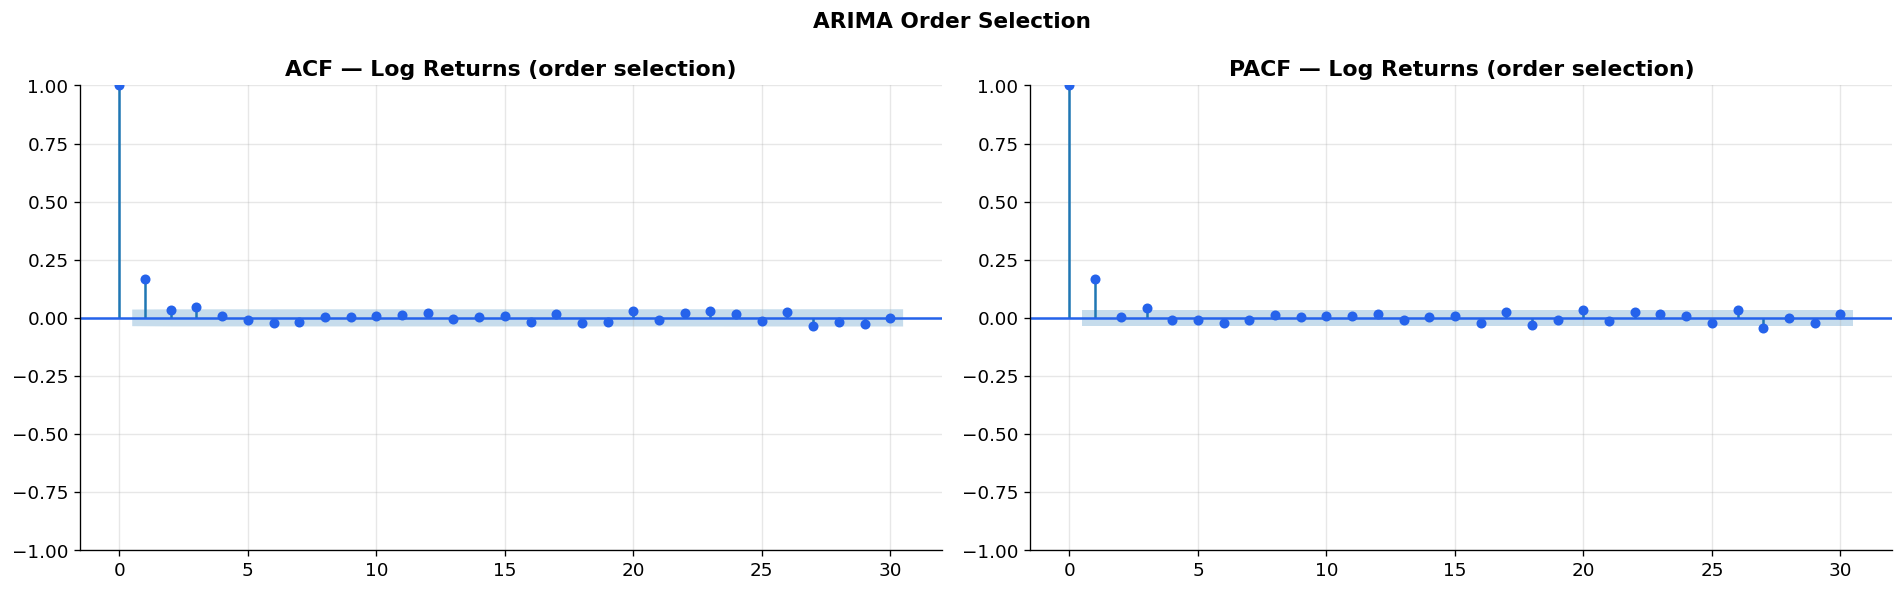

Both ACF and PACF cut off quickly → low AR and MA orders appropriate → ARIMA(0,0,2)


In [21]:
returns = df['Log_Return'].dropna()

# ADF test
adf_result = adfuller(returns)
print('ADF Test on Log Returns')
print(f'  Statistic : {adf_result[0]:.4f}')
print(f'  p-value   : {adf_result[1]:.6f}')
print(f'  Result    : {"STATIONARY" if adf_result[1]<0.05 else "NON-STATIONARY"} ✓')
print()

# ACF / PACF to pick ARIMA order
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(returns,  lags=30, ax=axes[0], color=COLORS['blue'])
axes[0].set_title('ACF — Log Returns (order selection)', fontweight='bold')
plot_pacf(returns, lags=30, ax=axes[1], color=COLORS['blue'])
axes[1].set_title('PACF — Log Returns (order selection)', fontweight='bold')
plt.suptitle('ARIMA Order Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('13_arima_order_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Both ACF and PACF cut off quickly → low AR and MA orders appropriate → ARIMA(0,0,2)')

### 7.2 — Train/Test Split & Model Fitting

In [22]:
# Chronological split — NEVER shuffle time-series data
# Shuffling causes data leakage: future data leaks into training, inflating performance
# ARIMA(p,d,q): p=AR order, d=differencing, q=MA order
# d=0: returns are already stationary (ADF confirmed in Phase 4)
# p=0: ACF/PACF showed no significant autoregressive structure
# q=2: MA terms at lags 1 and 2 were statistically significant

# Chronological 85/15 split
n         = len(returns)
split     = int(n * 0.85)
train_ret = returns.iloc[:split]
test_ret  = returns.iloc[split:]

print(f'Train: {len(train_ret):,} observations | {train_ret.index[0].date()} → {train_ret.index[-1].date()}')
print(f'Test : {len(test_ret):,}  observations | {test_ret.index[0].date()} → {test_ret.index[-1].date()}')
print()
print('Fitting ARIMA(0,0,2) on training data...')
print('Note: AR terms from initial ARIMA(2,0,2) were statistically insignificant (p=0.69, p=0.16)')
print('      Only MA.L2 was significant (p=0.022) → reduced to ARIMA(0,0,2)')
print()

arima_model = ARIMA(train_ret, order=(0,0,2)).fit()
print(arima_model.summary())

Train: 2,550 observations | 2014-01-05 → 2024-07-01
Test : 450  observations | 2024-07-02 → 2026-05-05

Fitting ARIMA(0,0,2) on training data...
Note: AR terms from initial ARIMA(2,0,2) were statistically insignificant (p=0.69, p=0.16)
      Only MA.L2 was significant (p=0.022) → reduced to ARIMA(0,0,2)

                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                 2550
Model:                 ARIMA(0, 0, 2)   Log Likelihood                7295.695
Date:                Sat, 09 May 2026   AIC                         -14583.390
Time:                        00:43:21   BIC                         -14560.015
Sample:                             0   HQIC                        -14574.912
                               - 2550                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0

### 7.3 — Forecast on Test Set

ARIMA(0,0,2) Test Set Results
  RMSE               : 0.011176
  MAE                : 0.008303
  Directional Acc.   : 59.56%


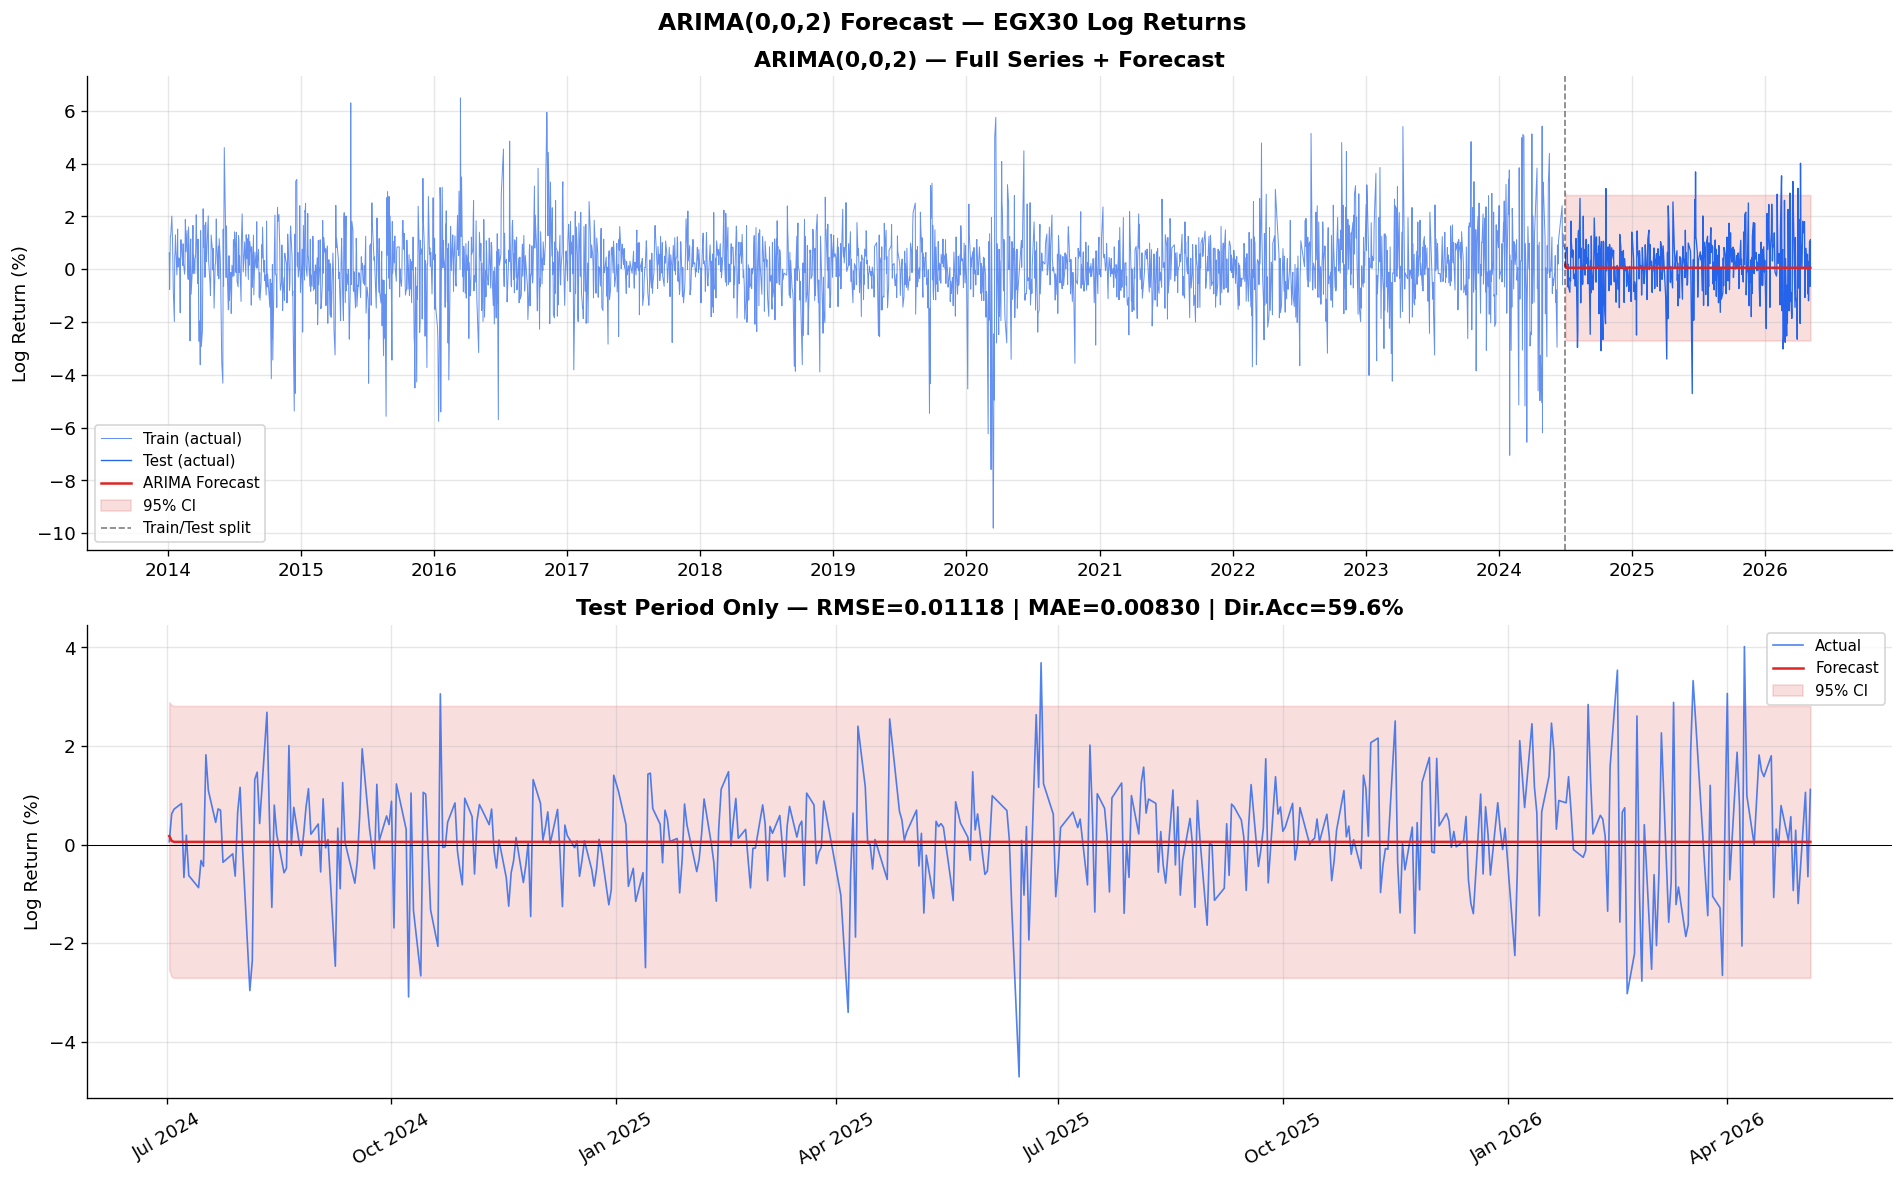

In [23]:
# RMSE penalizes large errors more — sensitive to outliers
# MAE is the average absolute error — more interpretable in original units
# Directional accuracy: % of days where we correctly predict up or down
# DA is arguably the most practically relevant metric for financial forecasting

forecast_obj    = arima_model.get_forecast(steps=len(test_ret))
forecast_mean   = forecast_obj.predicted_mean
forecast_ci     = forecast_obj.conf_int(alpha=0.05)
forecast_mean.index = test_ret.index
forecast_ci.index   = test_ret.index

# Metrics
rmse = np.sqrt(mean_squared_error(test_ret, forecast_mean))
mae  = mean_absolute_error(test_ret, forecast_mean)
da   = np.mean(np.sign(test_ret.values) == np.sign(forecast_mean.values)) * 100

print(f'ARIMA(0,0,2) Test Set Results')
print(f'  RMSE               : {rmse:.6f}')
print(f'  MAE                : {mae:.6f}')
print(f'  Directional Acc.   : {da:.2f}%')

# Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Full returns + forecast window
axes[0].plot(train_ret.index, train_ret*100,
             color=COLORS['blue'], linewidth=0.6, alpha=0.7, label='Train (actual)')
axes[0].plot(test_ret.index, test_ret*100,
             color=COLORS['blue'], linewidth=0.8, label='Test (actual)')
axes[0].plot(forecast_mean.index, forecast_mean*100,
             color=COLORS['red'], linewidth=1.5, label='ARIMA Forecast')
axes[0].fill_between(forecast_ci.index,
                     forecast_ci.iloc[:,0]*100,
                     forecast_ci.iloc[:,1]*100,
                     color=COLORS['red'], alpha=0.15, label='95% CI')
axes[0].axvline(test_ret.index[0], color='black', linestyle='--',
                linewidth=1, alpha=0.5, label='Train/Test split')
axes[0].set_title('ARIMA(0,0,2) — Full Series + Forecast', fontweight='bold')
axes[0].set_ylabel('Log Return (%)')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Zoom in on test period
axes[1].plot(test_ret.index, test_ret*100,
             color=COLORS['blue'], linewidth=1, alpha=0.8, label='Actual')
axes[1].plot(forecast_mean.index, forecast_mean*100,
             color=COLORS['red'], linewidth=1.5, label='Forecast')
axes[1].fill_between(forecast_ci.index,
                     forecast_ci.iloc[:,0]*100,
                     forecast_ci.iloc[:,1]*100,
                     color=COLORS['red'], alpha=0.15, label='95% CI')
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_title(f'Test Period Only — RMSE={rmse:.5f} | MAE={mae:.5f} | Dir.Acc={da:.1f}%',
                  fontweight='bold')
axes[1].set_ylabel('Log Return (%)')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('ARIMA(0,0,2) Forecast — EGX30 Log Returns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('14_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 — Residual Diagnostics

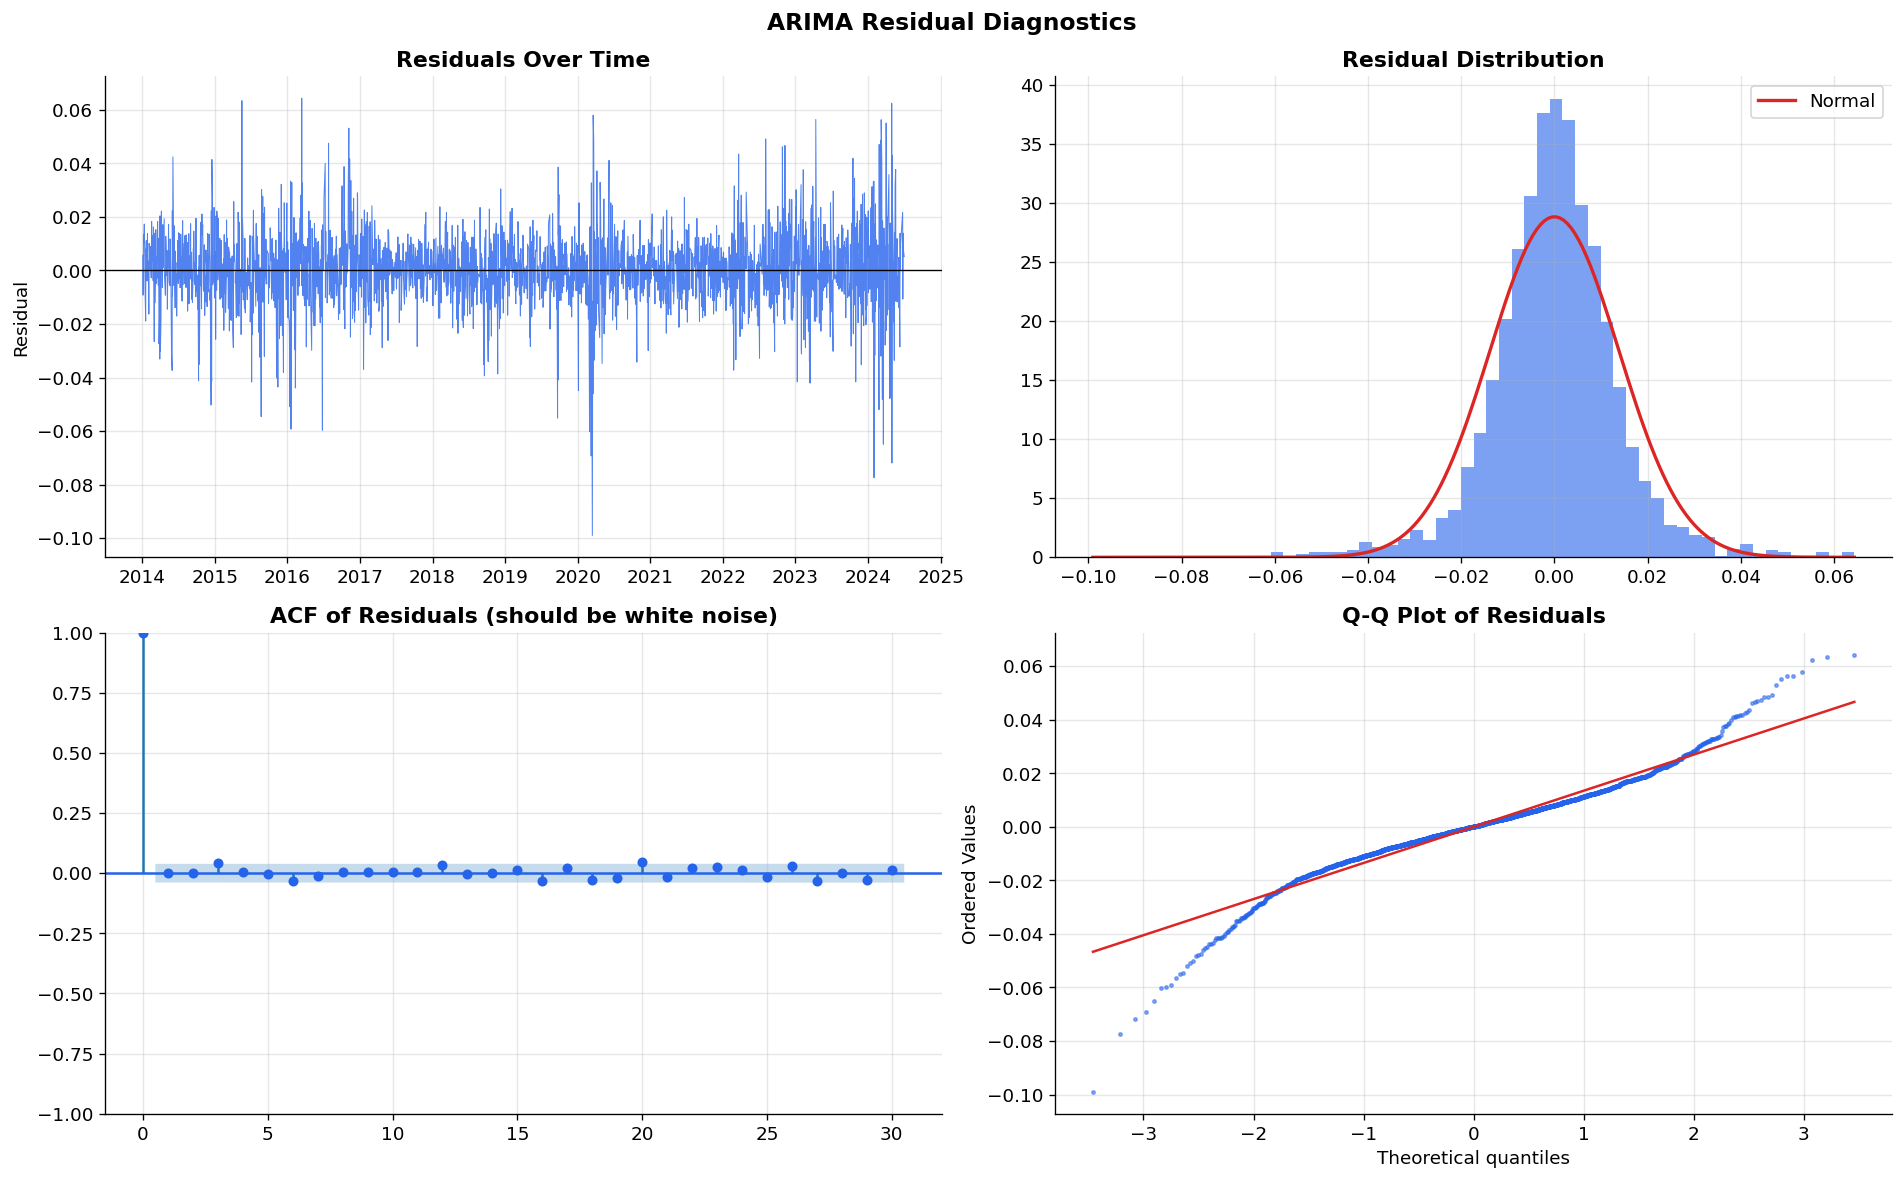

Ljung-Box Test (residuals should have no autocorrelation):
      lb_stat  lb_pvalue
10   7.904877   0.638128
20  23.925849   0.245646

If p-values > 0.05 → residuals are white noise → model is well-specified ✓


In [24]:
# Residual diagnostics check if the model captured all signal in the data
# A well-specified model leaves only white noise: random, uncorrelated residuals
# If residuals show patterns → the model is missing something important
# Ljung-Box test: H0 = residuals are not autocorrelated. We want p > 0.05
# Q-Q plot: tail deviations indicate fat-tailed residuals — common in financial data

residuals = arima_model.resid

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Residuals over time
axes[0,0].plot(residuals.index, residuals,
               color=COLORS['blue'], linewidth=0.6, alpha=0.8)
axes[0,0].axhline(0, color='black', linewidth=0.8)
axes[0,0].set_title('Residuals Over Time', fontweight='bold')
axes[0,0].set_ylabel('Residual')
axes[0,0].xaxis.set_major_locator(mdates.YearLocator())
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Residual distribution
axes[0,1].hist(residuals, bins=60, density=True,
               color=COLORS['blue'], alpha=0.6)
xr = np.linspace(residuals.min(), residuals.max(), 200)
axes[0,1].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()),
               color=COLORS['red'], linewidth=2, label='Normal')
axes[0,1].set_title('Residual Distribution', fontweight='bold')
axes[0,1].legend()

# ACF of residuals
plot_acf(residuals, lags=30, ax=axes[1,0], color=COLORS['blue'])
axes[1,0].set_title('ACF of Residuals (should be white noise)', fontweight='bold')

# Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot of Residuals', fontweight='bold')
axes[1,1].get_lines()[0].set(color=COLORS['blue'], markersize=2, alpha=0.5)
axes[1,1].get_lines()[1].set(color=COLORS['red'])

plt.suptitle('ARIMA Residual Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('15_arima_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# Ljung-Box test for residual autocorrelation
lb = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print('Ljung-Box Test (residuals should have no autocorrelation):')
print(lb)
print()
print('If p-values > 0.05 → residuals are white noise → model is well-specified ✓')

### 7.5 — Interpretation

In [25]:
print('='*60)
print('  ARIMA FORECASTING — ANALYTICAL CONCLUSION')
print('='*60)
print(f'  Model          : ARIMA(0,0,2)')
print(f'  Note           : AR terms dropped — statistically insignificant')
print(f'                   Only MA.L2 significant (p=0.022)')
print(f'  Target         : Log Returns (stationary, ADF confirmed)')
print(f'  Train period   : {train_ret.index[0].date()} → {train_ret.index[-1].date()}')
print(f'  Test period    : {test_ret.index[0].date()} → {test_ret.index[-1].date()}')
print(f'  RMSE           : {rmse:.6f}')
print(f'  MAE            : {mae:.6f}')
print(f'  Directional Acc: {da:.2f}%')
print()
print('  INTERPRETATION:')
print(f'  A directional accuracy of {da:.1f}% means the ARIMA model')
print('  correctly predicts the sign of next-day returns slightly')
print('  above random chance (50%). This is consistent with the')
print('  EDA finding that EGX30 returns show minimal autocorrelation,')
print('  suggesting the index operates near weak-form efficiency.')
print('  The insignificance of AR terms confirms there is no meaningful')
print('  autoregressive structure in returns — only a weak moving-average')
print('  component (MA.L2) survives, reinforcing the efficiency finding.')
print('  The model cannot reliably predict magnitude, consistent with')
print('  the strong volatility clustering observed in Section 5.3.')
print('='*60)

  ARIMA FORECASTING — ANALYTICAL CONCLUSION
  Model          : ARIMA(0,0,2)
  Note           : AR terms dropped — statistically insignificant
                   Only MA.L2 significant (p=0.022)
  Target         : Log Returns (stationary, ADF confirmed)
  Train period   : 2014-01-05 → 2024-07-01
  Test period    : 2024-07-02 → 2026-05-05
  RMSE           : 0.011176
  MAE            : 0.008303
  Directional Acc: 59.56%

  INTERPRETATION:
  A directional accuracy of 59.6% means the ARIMA model
  correctly predicts the sign of next-day returns slightly
  above random chance (50%). This is consistent with the
  EDA finding that EGX30 returns show minimal autocorrelation,
  suggesting the index operates near weak-form efficiency.
  The insignificance of AR terms confirms there is no meaningful
  autoregressive structure in returns — only a weak moving-average
  component (MA.L2) survives, reinforcing the efficiency finding.
  The model cannot reliably predict magnitude, consistent with
  the

---
## 💾 Export All Figures

In [26]:
import os, zipfile
from google.colab import files

# Zip all figures into one file — avoids Colab download throttle
zip_path = 'EGX30_figures.zip'
figures  = sorted([f for f in os.listdir('.') if f.endswith('.png')])

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in figures:
        zf.write(f)
        print(f'  Added: {f}')

print(f'\nZipped {len(figures)} figures → {zip_path}')
print(f'File size: {os.path.getsize(zip_path)/1024:.1f} KB')
files.download(zip_path)
print('Download started.')

  Added: 01_price_history.png
  Added: 02_returns_distribution.png
  Added: 03_volatility.png
  Added: 04_drawdown.png
  Added: 05_volume.png
  Added: 06_autocorrelation.png
  Added: 07_calendar_effects.png
  Added: 08_ramadan_effect.png
  Added: 09_event_analysis.png
  Added: 10_annual_returns.png
  Added: 11_technical_indicators.png
  Added: 12_correlation_heatmap.png
  Added: 13_arima_order_selection.png
  Added: 14_arima_forecast.png
  Added: 15_arima_residuals.png

Zipped 15 figures → EGX30_figures.zip
File size: 3335.6 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.


In [27]:
# download the cleaned dataset for external use (e.g. Power BI)
from google.colab import files
df.to_csv('EGX30_cleaned.csv')
files.download('EGX30_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## ✅ Project Complete — Phases 3 through 7

| Phase | What was done |
|-------|---------------|
| 3 | Loaded 2,991 trading days of EGX30 data (Jan 2014 – May 2026), verified integrity |
| 4 | Cleaned volume nulls, parsed dates, computed log returns, confirmed stationarity via ADF |
| 5 | Full EDA: price history, returns distribution, volatility clustering, drawdown (-52.85% max), volume analysis, autocorrelation, calendar effects, Ramadan effect, event analysis (4 shocks), risk metrics |
| 6 | Technical indicators: SMA/EMA (7/20/50/200), RSI, MACD, Bollinger Bands, ATR, correlation heatmap |
| 7 | ARIMA(0,0,2) forecasting as analytical conclusion: order selection, model fitting, forecast on test set, residual diagnostics, interpretation tied back to EDA findings |

**Next → Phase 8: IEEE Report, Dashboard, PowerPoint**